# Phase 1 Restart: EDA + Preprocessing + Spatial Grid Foundation

This notebook redoes Phase 1 with the requested scope:
- strong EDA + preprocessing for all four datasets,
- **Step 1:** project latitude/longitude to a metric CRS,
- **Step 2:** create a **sparse spatial base grid** (occupied cells only).

Clustering is intentionally excluded in this notebook and will be handled in the next phase.


## Scope and Method

We treat this as a multi-layer spatial foundation problem:
1. clean each source with explicit logging,
2. inspect quality and distributional behavior,
3. convert all points to a projected system for distance-safe operations,
4. build a sparse grid where each occupied cell is a micro-geographic unit for future feature aggregation and clustering.

This notebook ends at grid creation.


## Explanation Pattern

Each major section follows:
- **Question**
- **Method**
- **What we found**
- **Why this matters for next-phase clustering**


In [132]:
!pip install plotly

In [133]:
!pip install pyproj

In [134]:
from pathlib import Path
import re
import time
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from pyproj import Transformer

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 180)
sns.set_theme(style='whitegrid', context='notebook')

NOTEBOOK_START = time.time()

DATA_DIR = Path('../data')
OUTPUT_DIR = Path('../outputs/eda')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

TORONTO_BBOX = {
    'lat_min': 43.55,
    'lat_max': 43.90,
    'lon_min': -79.65,
    'lon_max': -79.10,
}

CELL_SIZE_M = 500
MIN_RENTALS_PER_CELL = 5
PROJECTED_CRS = 'EPSG:32617'  # UTM zone 17N (Toronto area)
GEODETIC_CRS = 'EPSG:4326'

## Data Ingestion + Raw Audit

**Question:** What is the baseline quality profile before preprocessing?

**Method:** Load all datasets and compute rows, columns, duplicate rows, missingness, coordinate validity, and Toronto bbox coverage.

**What we found:** The audit table and missingness charts expose where cleaning effort is needed.

**Why this matters for next-phase clustering:** Reliable clustering starts with reliable inputs.


In [135]:
def clean_columns(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out.columns = [str(c).replace('ï»¿', '').strip() for c in out.columns]
    return out


def to_numeric(series: pd.Series) -> pd.Series:
    return pd.to_numeric(series, errors='coerce')


def valid_coord_mask(df: pd.DataFrame, lat_col: str, lon_col: str) -> pd.Series:
    lat = to_numeric(df[lat_col])
    lon = to_numeric(df[lon_col])
    return lat.notna() & lon.notna() & lat.between(-90, 90) & lon.between(-180, 180)


def bbox_mask(df: pd.DataFrame, lat_col: str, lon_col: str) -> pd.Series:
    lat = to_numeric(df[lat_col])
    lon = to_numeric(df[lon_col])
    return lat.between(TORONTO_BBOX['lat_min'], TORONTO_BBOX['lat_max']) & lon.between(TORONTO_BBOX['lon_min'], TORONTO_BBOX['lon_max'])


def parse_currency(value):
    if pd.isna(value):
        return np.nan
    return pd.to_numeric(str(value).replace('$', '').replace(',', '').strip(), errors='coerce')


def parse_bedroom_count(value):
    if pd.isna(value):
        return np.nan

    text = str(value).strip().lower()
    if text in {'studio', 'bachelor'}:
        return 0.0

    nums = re.findall(r'\d+(?:\.\d+)?', text)
    if not nums:
        return np.nan
    return float(nums[0])


def normalize_rest_price(value):
    mapping = {
        'Under $10': 10.0,
        '$11-30': 20.5,
        '$31-60': 45.5,
        'Above $61': 70.0,
        'US$11-30': 20.5,
    }
    if pd.isna(value):
        return np.nan
    text = str(value).strip()
    if text in mapping:
        return mapping[text]

    nums = [int(n) for n in re.findall(r'\d+', text)]
    if len(nums) >= 2:
        return (nums[0] + nums[1]) / 2.0
    if len(nums) == 1:
        return float(nums[0])
    return np.nan


def winsorize_series(series: pd.Series, q_low=0.01, q_high=0.99):
    low, high = series.quantile([q_low, q_high])
    return series.clip(lower=low, upper=high), float(low), float(high)


crime_raw = clean_columns(pd.read_csv(DATA_DIR / 'MCI_2014_to_2019.csv'))
rent_2018_raw = clean_columns(pd.read_csv(DATA_DIR / 'Toronto_apartment_rentals_2018.csv'))
rest_raw = clean_columns(pd.read_csv(DATA_DIR / 'trt_rest.csv'))
subway_raw = clean_columns(pd.read_csv(DATA_DIR / 'toronto_subway_stations.csv'))

rent_2018_raw = rent_2018_raw.copy()
rent_2018_raw['rental_source'] = 'toronto_apartment_rentals_2018'

rent_core_cols = ['Bedroom', 'Bathroom', 'Den', 'Address', 'Lat', 'Long', 'Price', 'rental_source']
rent_base = rent_2018_raw.copy()
for col in rent_core_cols:
    if col not in rent_base.columns:
        rent_base[col] = pd.NA
rent_base = rent_base[rent_core_cols]

rentfaster_path = DATA_DIR / 'rentfaster.csv'
if rentfaster_path.exists():
    rentfaster_raw = clean_columns(pd.read_csv(rentfaster_path))
    rentfaster_norm = rentfaster_raw.copy()
    rentfaster_norm['Bedroom'] = rentfaster_norm['beds'].apply(parse_bedroom_count)
    rentfaster_norm['Bathroom'] = to_numeric(rentfaster_norm['baths'])
    rentfaster_norm['Den'] = 0

    street = rentfaster_norm['address'].astype('string').fillna('').str.strip()
    city = rentfaster_norm['city'].astype('string').fillna('').str.strip()
    province = rentfaster_norm['province'].astype('string').fillna('').str.strip()
    rentfaster_norm['Address'] = (
        street
        + np.where(city.ne(''), ', ' + city, '')
        + np.where(province.ne(''), ', ' + province, '')
    ).str.strip(', ')

    rentfaster_norm['Lat'] = to_numeric(rentfaster_norm['latitude'])
    rentfaster_norm['Long'] = to_numeric(rentfaster_norm['longitude'])
    rentfaster_norm['Price'] = rentfaster_norm['price']
    rentfaster_norm['rental_source'] = 'rentfaster'

    rentfaster_for_merge = rentfaster_norm[rent_core_cols]
    rent_raw = pd.concat([rent_base, rentfaster_for_merge], ignore_index=True)
else:
    rent_raw = rent_base.copy()

raw_datasets = {
    'crime': crime_raw,
    'rentals': rent_raw,
    'restaurants': rest_raw,
    'subway': subway_raw,
}

coord_cols = {
    'crime': ('Lat', 'Long'),
    'rentals': ('Lat', 'Long'),
    'restaurants': ('Restaurant Latitude', 'Restaurant Longitude'),
    'subway': ('latitude', 'longitude'),
}

audit_rows = []
for name, df in raw_datasets.items():
    lat_col, lon_col = coord_cols[name]
    valid = valid_coord_mask(df, lat_col, lon_col)
    bbox = bbox_mask(df, lat_col, lon_col)

    audit_rows.append({
        'dataset': name,
        'rows': int(df.shape[0]),
        'columns': int(df.shape[1]),
        'duplicate_rows': int(df.duplicated().sum()),
        'missingness_pct': round(float(df.isna().sum().sum() / (df.shape[0] * df.shape[1]) * 100), 4),
        'coord_valid_pct': round(float(valid.mean() * 100), 4),
        'toronto_bbox_coverage_pct': round(float(bbox.mean() * 100), 4),
    })

audit_df = pd.DataFrame(audit_rows).sort_values('dataset').reset_index(drop=True)
audit_df.to_csv(OUTPUT_DIR / 'data_quality_audit.csv', index=False)
audit_df


,dataset,rows,columns,duplicate_rows,missingness_pct,coord_valid_pct,toronto_bbox_coverage_pct
0,crime,206435,29,0,0.0049,100.0000,100.0000
1,rentals,1722,8,308,0.0000,100.0000,92.2764
2,restaurants,15821,9,6,7.0048,99.6966,99.3742
3,subway,69,3,0,0.0000,100.0000,100.0000


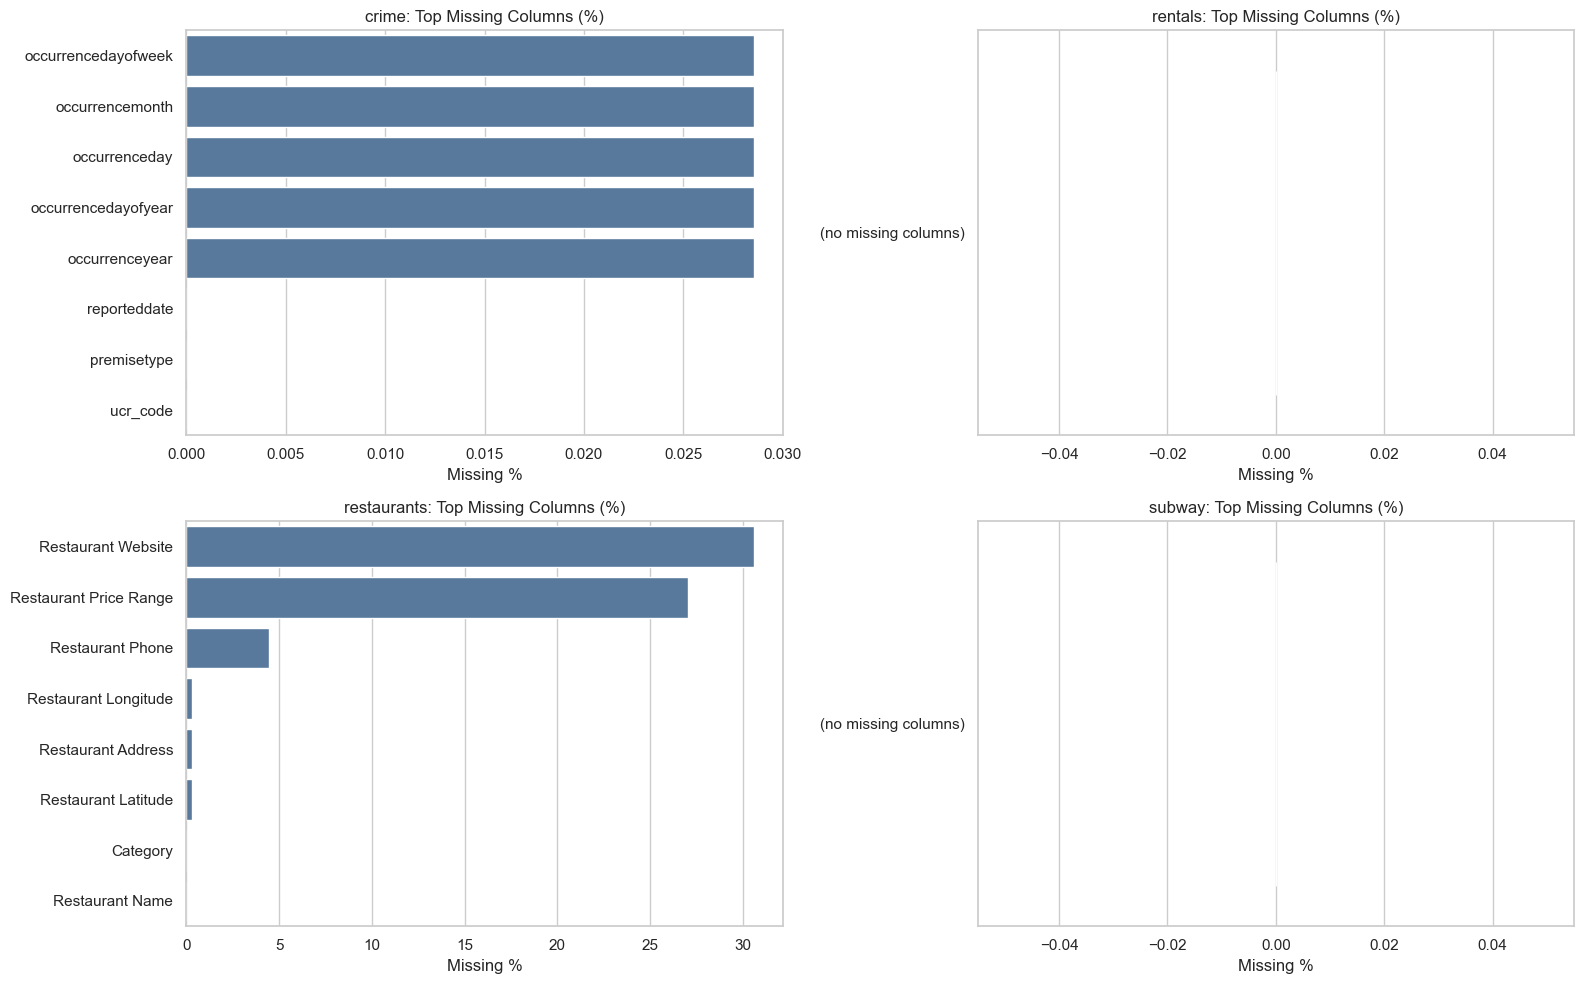

In [136]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.ravel()

for ax, (name, df) in zip(axes, raw_datasets.items()):
    miss = (df.isna().mean() * 100).sort_values(ascending=False).head(8)
    if miss.sum() == 0:
        miss = pd.Series({'(no missing columns)': 0.0})
    sns.barplot(x=miss.values, y=miss.index, ax=ax, color='#4C78A8')
    ax.set_title(f'{name}: Top Missing Columns (%)')
    ax.set_xlabel('Missing %')
    ax.set_ylabel('')

plt.tight_layout()
plt.show()

## Preprocessing Engine

**Question:** How do we apply deterministic preprocessing with traceability?

**Method:** Use reusable filter/dedup helpers with step-level drop logging.

**What we found:** Each transformation is accounted for in a drop log table.

**Why this matters for next-phase clustering:** Reproducibility and auditability are critical for team confidence and model governance.


In [137]:
drop_log = []


def log_step(dataset: str, step: str, before: int, after: int, detail: str = ''):
    dropped = int(before - after)
    drop_log.append({
        'dataset': dataset,
        'step': step,
        'rows_before': int(before),
        'rows_after': int(after),
        'dropped_rows': dropped,
        'drop_pct': 0.0 if before == 0 else round(dropped / before * 100, 4),
        'detail': detail,
    })


def apply_filter(df: pd.DataFrame, mask: pd.Series, dataset: str, step: str, detail: str = '') -> pd.DataFrame:
    before = len(df)
    out = df.loc[mask].copy()
    log_step(dataset, step, before, len(out), detail)
    return out


def apply_dedup(df: pd.DataFrame, subset, dataset: str, step: str) -> pd.DataFrame:
    before = len(df)
    out = df.drop_duplicates(subset=subset).copy()
    log_step(dataset, step, before, len(out), f'subset={subset}')
    return out

## Preprocess Crime, Rentals, Restaurants, Subway

**Question:** What cleaned point-level data should feed spatial grid construction?

**Method:** Apply dataset-specific cleaning rules for temporal validity, duplicates, coordinates, plausibility limits, and pricing normalization.

**What we found:** Final cleaned datasets are compact, consistent, and coordinate-safe.

**Why this matters for next-phase clustering:** Better point quality means better spatial feature quality downstream.


In [138]:
# ----- Crime -----
crime = crime_raw.copy()
for col in crime.columns:
    if pd.api.types.is_object_dtype(crime[col]) or pd.api.types.is_string_dtype(crime[col]):
        crime[col] = crime[col].astype('string').str.strip()

crime['occurrenceyear'] = to_numeric(crime['occurrenceyear'])
crime['Lat'] = to_numeric(crime['Lat'])
crime['Long'] = to_numeric(crime['Long'])
crime['MCI'] = crime['MCI'].astype('string').str.strip()
crime['event_unique_id'] = crime['event_unique_id'].astype('string').str.strip()
crime['is_violent'] = crime['MCI'].str.lower().isin({'assault', 'robbery', 'homicide'}).astype(int)

crime = apply_filter(crime, crime['occurrenceyear'].between(2014, 2019, inclusive='both'), 'crime', 'keep_occurrenceyear_2014_2019')
crime = apply_filter(crime, crime[['Lat', 'Long', 'MCI']].notna().all(axis=1), 'crime', 'drop_missing_core_fields')
crime = apply_filter(crime, bbox_mask(crime, 'Lat', 'Long'), 'crime', 'toronto_bbox_filter')
crime = apply_dedup(crime, ['event_unique_id'], 'crime', 'dedup_event_unique_id')

# ----- Rentals -----
rent = rent_raw.copy()
for col in rent.columns:
    if pd.api.types.is_object_dtype(rent[col]) or pd.api.types.is_string_dtype(rent[col]):
        rent[col] = rent[col].astype('string').str.strip()

rent['Lat'] = to_numeric(rent['Lat'])
rent['Long'] = to_numeric(rent['Long'])
rent['Bedroom'] = to_numeric(rent['Bedroom'])
rent['Bathroom'] = to_numeric(rent['Bathroom'])
rent['Den'] = to_numeric(rent['Den'])
rent['Price_num'] = rent['Price'].apply(parse_currency)

rent = apply_dedup(rent, ['Address', 'Bedroom', 'Bathroom', 'Den', 'Lat', 'Long', 'Price'], 'rentals', 'dedup_listing_signature')
rent = apply_filter(rent, rent['Address'].astype('string').str.contains('Toronto', case=False, na=False), 'rentals', 'keep_address_contains_toronto')
rent = apply_filter(rent, rent[['Lat', 'Long', 'Bedroom', 'Bathroom', 'Price_num']].notna().all(axis=1), 'rentals', 'drop_missing_core_fields')
rent = apply_filter(rent, bbox_mask(rent, 'Lat', 'Long'), 'rentals', 'toronto_bbox_filter')
rent = apply_filter(rent, rent['Bedroom'].between(0, 6, inclusive='both'), 'rentals', 'bedroom_plausibility_0_6')
rent = apply_filter(rent, rent['Bathroom'].between(0, 5, inclusive='both'), 'rentals', 'bathroom_plausibility_0_5')
rent = apply_filter(rent, rent['Price_num'].between(400, 10000, inclusive='both'), 'rentals', 'price_plausibility_400_10000')

rent['Price_clean'], q01, q99 = winsorize_series(rent['Price_num'], 0.01, 0.99)
rent['price_was_winsorized'] = ((rent['Price_num'] < q01) | (rent['Price_num'] > q99)).astype(int)
rent['price_per_bedroom'] = rent['Price_clean'] / rent['Bedroom'].clip(lower=1)
log_step('rentals', 'winsorize_price_q01_q99', len(rent), len(rent), f'q01={q01:.2f};q99={q99:.2f};winsorized_rows={int(rent.price_was_winsorized.sum())}')

# ----- Restaurants -----
rest = rest_raw.copy()
for col in rest.columns:
    if pd.api.types.is_object_dtype(rest[col]) or pd.api.types.is_string_dtype(rest[col]):
        rest[col] = rest[col].astype('string').str.strip()

rest['Restaurant Latitude'] = to_numeric(rest['Restaurant Latitude'])
rest['Restaurant Longitude'] = to_numeric(rest['Restaurant Longitude'])
rest['Category'] = rest['Category'].astype('string').str.strip().replace({'<NA>': pd.NA}).fillna('Unknown')
rest['Restaurant Name'] = rest['Restaurant Name'].astype('string').str.strip()
rest['Restaurant Address'] = rest['Restaurant Address'].astype('string').str.strip()
rest['restaurant_price_mid'] = rest['Restaurant Price Range'].apply(normalize_rest_price)
rest['restaurant_price_missing_original'] = rest['restaurant_price_mid'].isna().astype(int)

rest = apply_filter(rest, rest[['Restaurant Latitude', 'Restaurant Longitude']].notna().all(axis=1), 'restaurants', 'drop_missing_coords')
rest = apply_filter(rest, bbox_mask(rest, 'Restaurant Latitude', 'Restaurant Longitude'), 'restaurants', 'toronto_bbox_filter')
rest = apply_filter(rest, rest['Restaurant Address'].astype('string').str.contains('Toronto', case=False, na=False), 'restaurants', 'keep_address_contains_toronto')

cat_median = rest.groupby('Category')['restaurant_price_mid'].transform('median')
rest['restaurant_price_mid'] = rest['restaurant_price_mid'].fillna(cat_median)
rest_global_med = float(rest['restaurant_price_mid'].median())
rest['restaurant_price_mid'] = rest['restaurant_price_mid'].fillna(rest_global_med)
log_step('restaurants', 'impute_restaurant_price_category_then_global', len(rest), len(rest), f'global_median={rest_global_med:.2f}')

# venue-level for point density/grid occupancy
rest_venue = apply_dedup(rest, ['Restaurant Name', 'Restaurant Address', 'Restaurant Latitude', 'Restaurant Longitude'], 'restaurants', 'dedup_restaurant_venue_signature')

# ----- Subway -----
subway = subway_raw.copy()
for col in subway.columns:
    if pd.api.types.is_object_dtype(subway[col]) or pd.api.types.is_string_dtype(subway[col]):
        subway[col] = subway[col].astype('string').str.strip()

subway['latitude'] = to_numeric(subway['latitude'])
subway['longitude'] = to_numeric(subway['longitude'])
subway = apply_filter(subway, subway[['latitude', 'longitude']].notna().all(axis=1), 'subway', 'drop_missing_coords')
subway = apply_dedup(subway, ['name', 'latitude', 'longitude'], 'subway', 'dedup_station_signature')
subway = apply_filter(subway, bbox_mask(subway, 'latitude', 'longitude'), 'subway', 'toronto_bbox_filter')

cleaned_counts_df = pd.DataFrame([
    {'dataset': 'crime', 'rows_clean': len(crime)},
    {'dataset': 'rentals', 'rows_clean': len(rent)},
    {'dataset': 'restaurants_venue', 'rows_clean': len(rest_venue)},
    {'dataset': 'subway', 'rows_clean': len(subway)},
])

a = rent_raw['rental_source'].astype('string').fillna('unknown').value_counts().rename('rows_raw')
b = rent['rental_source'].astype('string').fillna('unknown').value_counts().rename('rows_clean')
rental_source_summary = (
    pd.concat([a, b], axis=1)
    .fillna(0)
    .astype(int)
    .reset_index()
    .rename(columns={'index': 'rental_source'})
    .sort_values('rows_clean', ascending=False)
    .reset_index(drop=True)
)

display(cleaned_counts_df)
rental_source_summary

,dataset,rows_clean
0,crime,178892
1,rentals,1191
2,restaurants_venue,6101
3,subway,69


,rental_source,rows_raw,rows_clean
0,rentfaster,598,596
1,toronto_apartment_rentals_2018,1124,595


## Preprocessing Log and Recap

**Question:** How many rows were removed by each preprocessing rule?

**Method:** Persist step-level drop log and summarize raw vs cleaned counts.

**What we found:** Most reductions come from duplicate and location validity controls.

**Why this matters for next-phase clustering:** Quantified preprocessing effects avoid hidden data shifts.


In [139]:
drop_log_df = pd.DataFrame(drop_log)
drop_log_df.to_csv(OUTPUT_DIR / 'preprocessing_drop_log.csv', index=False)

recap = pd.DataFrame([
    {'dataset': 'crime', 'rows_raw': len(crime_raw), 'rows_clean': len(crime)},
    {'dataset': 'rentals', 'rows_raw': len(rent_raw), 'rows_clean': len(rent)},
    {'dataset': 'restaurants', 'rows_raw': len(rest_raw), 'rows_clean': len(rest_venue)},
    {'dataset': 'subway', 'rows_raw': len(subway_raw), 'rows_clean': len(subway)},
])

recap

,dataset,rows_raw,rows_clean
0,crime,206435,178892
1,rentals,1722,1191
2,restaurants,15821,6101
3,subway,69,69


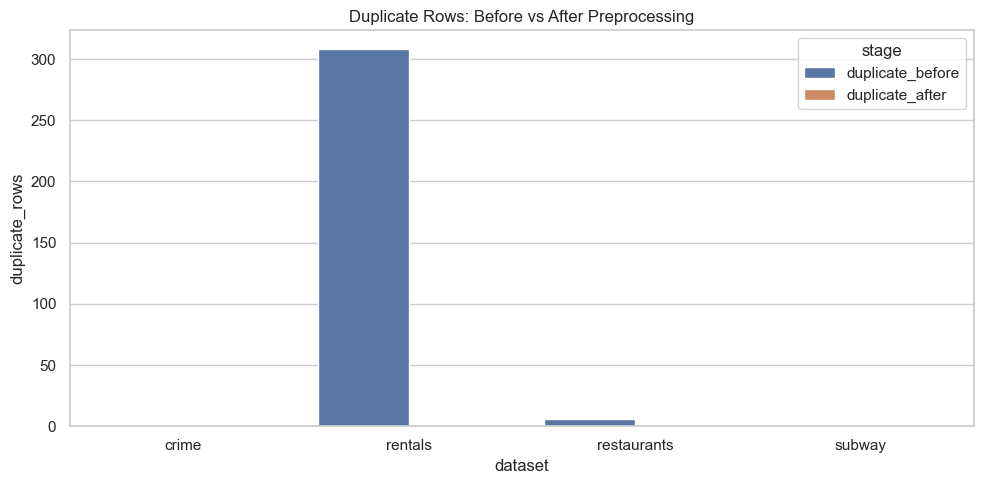

,dataset,duplicate_before,duplicate_after
0,crime,0,0
1,rentals,308,0
2,restaurants,6,0
3,subway,0,0


In [140]:
dup_summary = pd.DataFrame([
    {
        'dataset': name,
        'duplicate_before': int(raw_datasets[name].duplicated().sum()),
        'duplicate_after': int(df.duplicated().sum()),
    }
    for name, df in [('crime', crime), ('rentals', rent), ('restaurants', rest_venue), ('subway', subway)]
])

dup_long = dup_summary.melt(id_vars='dataset', var_name='stage', value_name='duplicate_rows')

plt.figure(figsize=(10, 5))
sns.barplot(data=dup_long, x='dataset', y='duplicate_rows', hue='stage')
plt.title('Duplicate Rows: Before vs After Preprocessing')
plt.tight_layout()
plt.show()

dup_summary

## EDA Highlights After Cleaning

**Question:** What are the cleaned distributions that will influence future clustering?

**Method:** Inspect temporal crime structure, rental price behavior, and amenity composition.

**What we found:** Core distributional patterns are visible and cleaner than raw data.

**Why this matters for next-phase clustering:** These are the feature-generating signals for later unsupervised learning.


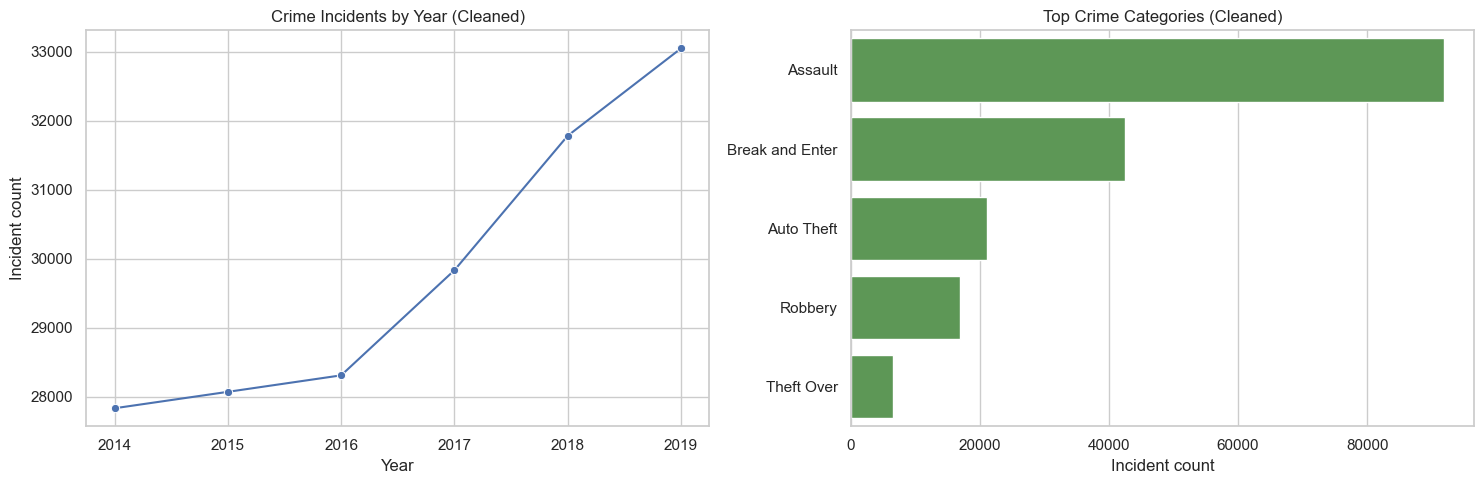

In [141]:
crime_year = (
    crime.groupby('occurrenceyear', as_index=False)
    .size()
    .rename(columns={'size': 'incident_count'})
    .sort_values('occurrenceyear')
)

top_mci = crime['MCI'].value_counts().head(12).rename_axis('MCI').reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.lineplot(data=crime_year, x='occurrenceyear', y='incident_count', marker='o', ax=axes[0])
axes[0].set_title('Crime Incidents by Year (Cleaned)')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Incident count')

sns.barplot(data=top_mci, y='MCI', x='count', ax=axes[1], color='#54A24B')
axes[1].set_title('Top Crime Categories (Cleaned)')
axes[1].set_xlabel('Incident count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

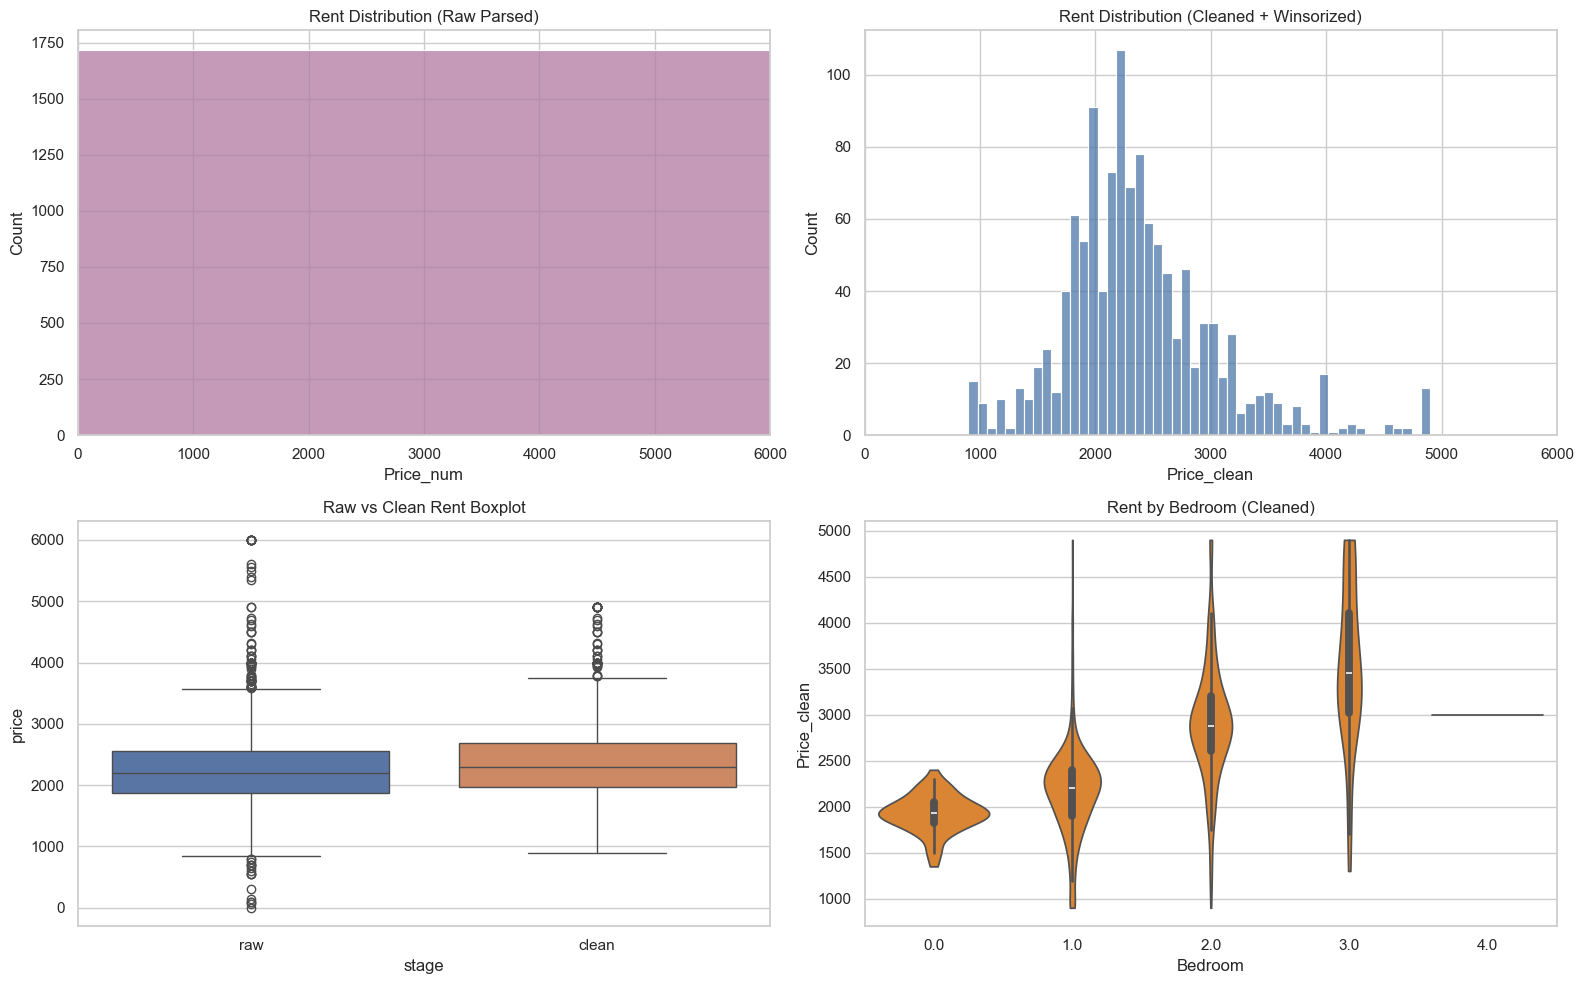

In [142]:
rent_before = rent_raw.copy()
rent_before['Price_num'] = rent_before['Price'].apply(parse_currency)
rent_before = rent_before[rent_before['Price_num'].notna()]

display_cap = np.nanpercentile(rent_before['Price_num'], 99.5)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.histplot(rent_before['Price_num'], bins=50, ax=axes[0, 0], color='#B279A2')
axes[0, 0].set_title('Rent Distribution (Raw Parsed)')
axes[0, 0].set_xlim(0, display_cap)

sns.histplot(rent['Price_clean'], bins=50, ax=axes[0, 1], color='#4C78A8')
axes[0, 1].set_title('Rent Distribution (Cleaned + Winsorized)')
axes[0, 1].set_xlim(0, display_cap)

box_df = pd.DataFrame({
    'raw': rent_before['Price_num'].clip(upper=display_cap),
    'clean': rent['Price_clean'].clip(upper=display_cap),
}).melt(var_name='stage', value_name='price')

sns.boxplot(data=box_df, x='stage', y='price', hue='stage', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Raw vs Clean Rent Boxplot')

sns.violinplot(data=rent[rent['Bedroom'].between(0, 6, inclusive='both')], x='Bedroom', y='Price_clean', ax=axes[1, 1], color='#F58518', cut=0)
axes[1, 1].set_title('Rent by Bedroom (Cleaned)')

plt.tight_layout()
plt.show()

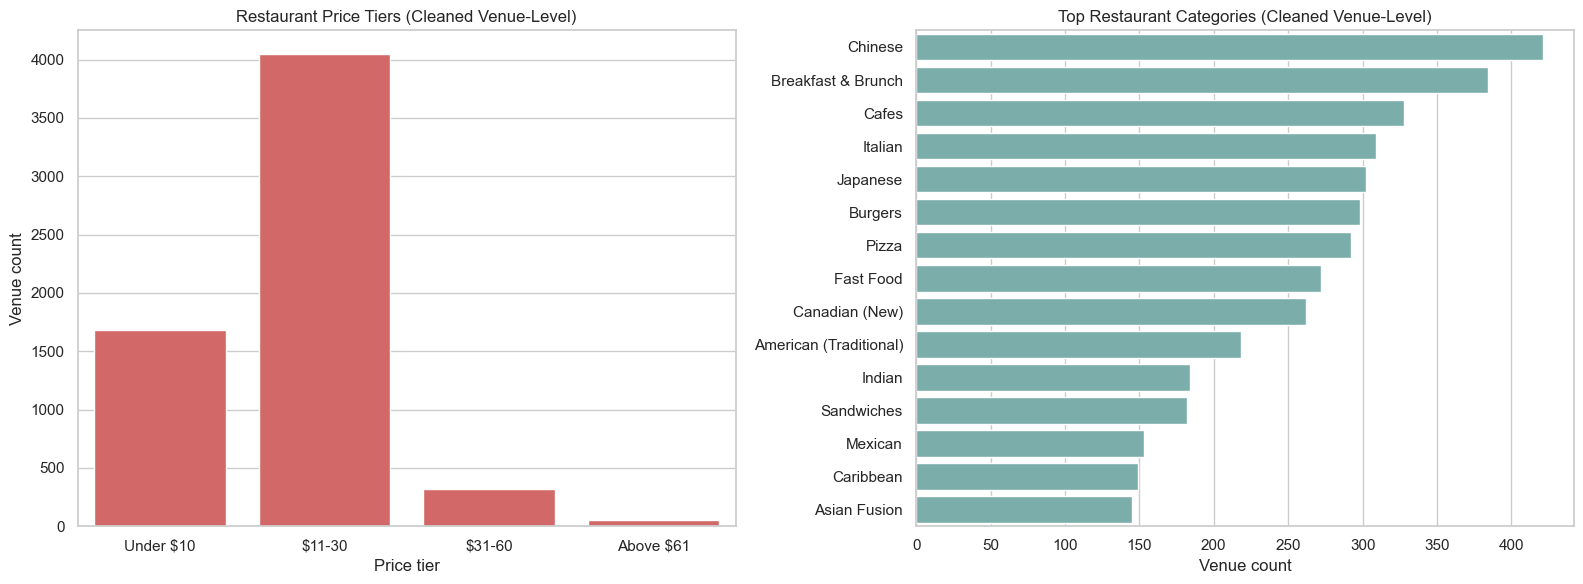

In [143]:
price_bins = pd.cut(
    rest_venue['restaurant_price_mid'],
    bins=[0, 10.5, 30.5, 60.5, np.inf],
    labels=['Under $10', '$11-30', '$31-60', 'Above $61'],
    include_lowest=True,
)

price_counts = price_bins.value_counts().rename_axis('price_range').reset_index(name='count')
top_categories = rest_venue['Category'].value_counts().head(15).rename_axis('Category').reset_index(name='count')

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.barplot(data=price_counts, x='price_range', y='count', ax=axes[0], color='#E45756')
axes[0].set_title('Restaurant Price Tiers (Cleaned Venue-Level)')
axes[0].set_xlabel('Price tier')
axes[0].set_ylabel('Venue count')

sns.barplot(data=top_categories, y='Category', x='count', ax=axes[1], color='#72B7B2')
axes[1].set_title('Top Restaurant Categories (Cleaned Venue-Level)')
axes[1].set_xlabel('Venue count')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Step 1: Standardize Coordinate System (Projected CRS)

**Question:** How do we convert all datasets into a distance-safe coordinate system?

**Method:** Transform from WGS84 (`EPSG:4326`) to UTM Zone 17N (`EPSG:32617`) using `pyproj`.

**What we found:** All cleaned points receive metric `x_m`/`y_m` coordinates.

**Why this matters for next-phase clustering:** Grid construction and distance-based analytics require projected coordinates in meters.


In [144]:
fwd_transformer = Transformer.from_crs(GEODETIC_CRS, PROJECTED_CRS, always_xy=True)
inv_transformer = Transformer.from_crs(PROJECTED_CRS, GEODETIC_CRS, always_xy=True)


def add_projected_xy(df: pd.DataFrame, lat_col: str, lon_col: str) -> pd.DataFrame:
    out = df.copy()
    lon = out[lon_col].to_numpy(dtype=float)
    lat = out[lat_col].to_numpy(dtype=float)
    x_m, y_m = fwd_transformer.transform(lon, lat)
    out['x_m'] = x_m
    out['y_m'] = y_m
    return out


crime_proj = add_projected_xy(crime, 'Lat', 'Long')
rent_proj = add_projected_xy(rent, 'Lat', 'Long')
rest_proj = add_projected_xy(rest_venue, 'Restaurant Latitude', 'Restaurant Longitude')
subway_proj = add_projected_xy(subway, 'latitude', 'longitude')

projected_summary = pd.DataFrame([
    {
        'dataset': 'crime',
        'rows': len(crime_proj),
        'x_min': float(crime_proj['x_m'].min()),
        'x_max': float(crime_proj['x_m'].max()),
        'y_min': float(crime_proj['y_m'].min()),
        'y_max': float(crime_proj['y_m'].max()),
    },
    {
        'dataset': 'rentals',
        'rows': len(rent_proj),
        'x_min': float(rent_proj['x_m'].min()),
        'x_max': float(rent_proj['x_m'].max()),
        'y_min': float(rent_proj['y_m'].min()),
        'y_max': float(rent_proj['y_m'].max()),
    },
    {
        'dataset': 'restaurants',
        'rows': len(rest_proj),
        'x_min': float(rest_proj['x_m'].min()),
        'x_max': float(rest_proj['x_m'].max()),
        'y_min': float(rest_proj['y_m'].min()),
        'y_max': float(rest_proj['y_m'].max()),
    },
    {
        'dataset': 'subway',
        'rows': len(subway_proj),
        'x_min': float(subway_proj['x_m'].min()),
        'x_max': float(subway_proj['x_m'].max()),
        'y_min': float(subway_proj['y_m'].min()),
        'y_max': float(subway_proj['y_m'].max()),
    },
])

projected_summary

,dataset,rows,x_min,x_max,y_min,y_max
0,crime,178892,609553.297485,651013.761687,4.827050e+06,4.856893e+06
1,rentals,1191,612698.979972,644629.813362,4.827254e+06,4.852476e+06
2,restaurants,6101,612524.964770,645595.345413,4.827639e+06,4.854102e+06
3,subway,69,618127.250702,639827.107006,4.832667e+06,4.848802e+06


## Step 2: Create Adaptive Sparse Grid (Equal-Rental-Count Circles)

**Question:** How do we build spatial units where low-density areas become larger and high-density areas become smaller without spatial overlap artifacts?

**Method:**
- Start from a very fine projected mesh (`100m x 100m`) and use occupied mesh cells as seed locations.
- Grow each seed cell outward ring-by-ring, collecting nearby rentals until exactly **3 rentals** are available.
- Stop growth immediately at 3 rentals and set the circle radius to the 3rd rental distance from the seed center.
- Enforce one-to-one rental membership (each rental can belong to only one adaptive cell).
- For crime/restaurants/subway counts, assign each point to its **nearest adaptive cell center** (no double counting across overlapping circles).

**What we found:** Adaptive cells now reflect local density while avoiding inflated counts caused by overlapping circle coverage.

**Why this matters for next-phase clustering:** Features become spatially stable and interpretable because each point contributes to exactly one adaptive unit.


In [145]:
K_RENTALS_PER_CELL = 3
MESH_CELL_SIZE_M = 100.0
MAX_GROWTH_RADIUS_M = 3000.0
MAX_RING_STEPS = int(np.ceil(MAX_GROWTH_RADIUS_M / MESH_CELL_SIZE_M))

from collections import defaultdict

rent_core = rent_proj[['x_m', 'y_m', 'Lat', 'Long', 'Price_clean', 'price_per_bedroom']].reset_index(drop=True)
rent_xy = rent_core[['x_m', 'y_m']].to_numpy(dtype=float)

# Build a fine projected mesh and attach each rental to a mesh cell.
mesh_origin_x = float(np.floor(rent_xy[:, 0].min() / MESH_CELL_SIZE_M) * MESH_CELL_SIZE_M)
mesh_origin_y = float(np.floor(rent_xy[:, 1].min() / MESH_CELL_SIZE_M) * MESH_CELL_SIZE_M)
grid_x = np.floor((rent_xy[:, 0] - mesh_origin_x) / MESH_CELL_SIZE_M).astype(int)
grid_y = np.floor((rent_xy[:, 1] - mesh_origin_y) / MESH_CELL_SIZE_M).astype(int)

rent_core['grid_x'] = grid_x
rent_core['grid_y'] = grid_y

cell_to_indices = defaultdict(set)
for idx, (gx, gy) in enumerate(zip(grid_x, grid_y)):
    cell_to_indices[(int(gx), int(gy))].add(int(idx))

unassigned = set(range(len(rent_core)))
blocked_seed_cells = set()
adaptive_rows = []
cell_id = 0


def ring_cells(seed_cell, ring):
    sx, sy = seed_cell
    if ring == 0:
        return [(sx, sy)]

    out = []
    for dx in range(-ring, ring + 1):
        out.append((sx + dx, sy - ring))
        out.append((sx + dx, sy + ring))
    for dy in range(-ring + 1, ring):
        out.append((sx - ring, sy + dy))
        out.append((sx + ring, sy + dy))
    return out


def active_seed_cells(cell_index_map, blocked_cells):
    ranked = []
    for cell_key, members in cell_index_map.items():
        if members and cell_key not in blocked_cells:
            ranked.append((len(members), cell_key[1], cell_key[0], cell_key))

    ranked.sort(key=lambda t: (-t[0], t[1], t[2]))
    return [t[3] for t in ranked]


while len(unassigned) >= K_RENTALS_PER_CELL:
    seeds = active_seed_cells(cell_to_indices, blocked_seed_cells)
    if not seeds:
        break

    seed_cell = seeds[0]
    sx, sy = seed_cell
    center_x = mesh_origin_x + (sx + 0.5) * MESH_CELL_SIZE_M
    center_y = mesh_origin_y + (sy + 0.5) * MESH_CELL_SIZE_M

    candidate_indices = set()
    ring_used = None

    # Grow from the seed mesh cell outward until we can form exactly K rentals.
    for ring in range(MAX_RING_STEPS + 1):
        for cell_key in ring_cells(seed_cell, ring):
            if cell_key in cell_to_indices:
                candidate_indices.update(cell_to_indices[cell_key])

        if len(candidate_indices) >= K_RENTALS_PER_CELL:
            ring_used = ring
            break

    # If this seed cannot find enough rentals within the growth cap, skip it.
    if ring_used is None:
        blocked_seed_cells.add(seed_cell)
        continue

    cand = np.array(sorted(candidate_indices), dtype=int)
    d = np.sqrt(((rent_xy[cand] - np.array([center_x, center_y])) ** 2).sum(axis=1))
    order = np.argsort(d)
    selected = cand[order[:K_RENTALS_PER_CELL]]
    kth_radius_m = float(d[order[K_RENTALS_PER_CELL - 1]])

    if kth_radius_m > MAX_GROWTH_RADIUS_M:
        blocked_seed_cells.add(seed_cell)
        continue

    radius_m = max(kth_radius_m, 1.0)

    rsub = rent_core.iloc[selected]
    adaptive_rows.append({
        'adaptive_cell_id': f'ac_{cell_id:04d}',
        'rental_count': int(len(selected)),
        'seed_grid_x': int(sx),
        'seed_grid_y': int(sy),
        'growth_rings': int(ring_used),
        'x_centroid': float(center_x),
        'y_centroid': float(center_y),
        'seed_local_k_radius_m': float(radius_m),
        'radius_m': float(radius_m),
        'mean_rent': float(rsub['Price_clean'].mean()),
        'median_rent': float(rsub['Price_clean'].median()),
        'mean_price_per_bedroom': float(rsub['price_per_bedroom'].mean()),
        'member_rental_idx': ','.join(map(str, selected.tolist())),
    })

    # Enforce non-overlap in rental membership.
    for ridx in selected:
        ridx = int(ridx)
        unassigned.discard(ridx)
        ckey = (int(grid_x[ridx]), int(grid_y[ridx]))
        if ckey in cell_to_indices and ridx in cell_to_indices[ckey]:
            cell_to_indices[ckey].remove(ridx)
            if len(cell_to_indices[ckey]) == 0:
                del cell_to_indices[ckey]

    blocked_seed_cells = {c for c in blocked_seed_cells if c in cell_to_indices}
    cell_id += 1

leftover_rental_indices = sorted(unassigned)
leftover_rentals = rent_core.iloc[leftover_rental_indices].copy() if leftover_rental_indices else pd.DataFrame(columns=rent_core.columns)

adaptive_grid = pd.DataFrame(adaptive_rows)

# Convert adaptive cell centers back to lon/lat for mapping and downstream joins.
c_lon, c_lat = inv_transformer.transform(adaptive_grid['x_centroid'].to_numpy(), adaptive_grid['y_centroid'].to_numpy())
adaptive_grid['centroid_lon'] = c_lon
adaptive_grid['centroid_lat'] = c_lat
adaptive_grid['cell_area_km2'] = np.pi * (adaptive_grid['radius_m'] ** 2) / 1_000_000

# Prepare projected point arrays for layer-level counts.
crime_xy = crime_proj[['x_m', 'y_m']].to_numpy(dtype=float)
rest_xy = rest_proj[['x_m', 'y_m']].to_numpy(dtype=float)
subway_xy = subway_proj[['x_m', 'y_m']].to_numpy(dtype=float)
crime_violent = crime_proj['is_violent'].to_numpy(dtype=int)

centers_xy = adaptive_grid[['x_centroid', 'y_centroid']].to_numpy(dtype=float)


def assign_to_nearest_center(points_xy, center_xy, chunk_size=20000):
    if len(points_xy) == 0:
        return np.array([], dtype=int), np.array([], dtype=float)

    assigned_idx = np.empty(len(points_xy), dtype=int)
    assigned_dist = np.empty(len(points_xy), dtype=float)

    for start in range(0, len(points_xy), chunk_size):
        end = min(start + chunk_size, len(points_xy))
        block = points_xy[start:end]
        d2 = ((block[:, None, :] - center_xy[None, :, :]) ** 2).sum(axis=2)
        nn = np.argmin(d2, axis=1)
        assigned_idx[start:end] = nn
        assigned_dist[start:end] = np.sqrt(d2[np.arange(len(block)), nn])

    return assigned_idx, assigned_dist


# Non-overlap counting: each point is assigned to exactly one adaptive cell center.
crime_assign_idx, crime_assign_dist = assign_to_nearest_center(crime_xy, centers_xy)
rest_assign_idx, rest_assign_dist = assign_to_nearest_center(rest_xy, centers_xy)
subway_assign_idx, subway_assign_dist = assign_to_nearest_center(subway_xy, centers_xy)

crime_counts = np.bincount(crime_assign_idx, minlength=len(adaptive_grid)).astype(int)
violent_counts = np.bincount(crime_assign_idx, weights=crime_violent.astype(float), minlength=len(adaptive_grid)).round().astype(int)
restaurant_counts = np.bincount(rest_assign_idx, minlength=len(adaptive_grid)).astype(int)
subway_counts = np.bincount(subway_assign_idx, minlength=len(adaptive_grid)).astype(int)

adaptive_grid['crime_count_in_circle'] = crime_counts
adaptive_grid['violent_crime_count_in_circle'] = violent_counts
adaptive_grid['violent_crime_ratio_in_circle'] = np.where(
    adaptive_grid['crime_count_in_circle'] > 0,
    adaptive_grid['violent_crime_count_in_circle'] / adaptive_grid['crime_count_in_circle'],
    0.0,
)
adaptive_grid['restaurant_count_in_circle'] = restaurant_counts
adaptive_grid['subway_count_in_circle'] = subway_counts
adaptive_grid['crime_assignment_median_dist_m'] = float(np.median(crime_assign_dist)) if len(crime_assign_dist) else 0.0
adaptive_grid['restaurant_assignment_median_dist_m'] = float(np.median(rest_assign_dist)) if len(rest_assign_dist) else 0.0
adaptive_grid['subway_assignment_median_dist_m'] = float(np.median(subway_assign_dist)) if len(subway_assign_dist) else 0.0

adaptive_grid = adaptive_grid.sort_values('adaptive_cell_id').reset_index(drop=True)
adaptive_output = OUTPUT_DIR / f'adaptive_sparse_grid_rentals_k{K_RENTALS_PER_CELL}.csv'
adaptive_grid.to_csv(adaptive_output, index=False)

adaptive_grid.head(10)


,adaptive_cell_id,rental_count,seed_grid_x,seed_grid_y,growth_rings,x_centroid,y_centroid,seed_local_k_radius_m,radius_m,mean_rent,median_rent,mean_price_per_bedroom,member_rental_idx,centroid_lon,centroid_lat,cell_area_km2,crime_count_in_circle,violent_crime_count_in_circle,violent_crime_ratio_in_circle,restaurant_count_in_circle,subway_count_in_circle,crime_assignment_median_dist_m,restaurant_assignment_median_dist_m,subway_assignment_median_dist_m
0,ac_0000,3,170,67,0,629650.0,4833950.0,33.517635,33.517635,2150.000000,2100.0,1733.333333,"62,86,96",-79.392399,43.647246,0.003529,102,70,0.686275,12,0,673.752858,290.340158,394.397596
1,ac_0001,3,181,82,0,630750.0,4835450.0,19.721210,19.721210,1983.333333,2000.0,1983.333333,"217,1,81",-79.378401,43.660554,0.001222,354,238,0.672316,12,0,673.752858,290.340158,394.397596
2,ac_0002,3,179,61,0,630550.0,4833350.0,39.911398,39.911398,2033.333333,2050.0,2033.333333,"47,186,404",-79.381389,43.641688,0.005004,124,77,0.620968,3,0,673.752858,290.340158,394.397596
3,ac_0003,3,170,67,0,629650.0,4833950.0,33.517635,33.517635,2113.333333,2100.0,2113.333333,"98,149,170",-79.392399,43.647246,0.003529,0,0,0.000000,0,0,673.752858,290.340158,394.397596
4,ac_0004,3,181,61,0,630750.0,4833350.0,16.590649,16.590649,2483.333333,2550.0,2483.333333,"165,377,338",-79.378910,43.641653,0.000865,84,78,0.928571,13,0,673.752858,290.340158,394.397596
5,ac_0005,3,181,82,0,630750.0,4835450.0,19.721210,19.721210,2316.666667,2300.0,1850.000000,"79,97,151",-79.378401,43.660554,0.001222,0,0,0.000000,0,0,673.752858,290.340158,394.397596
6,ac_0006,3,179,61,0,630550.0,4833350.0,39.911398,39.911398,3766.666667,3800.0,1400.000000,"294,434,468",-79.381389,43.641688,0.005004,0,0,0.000000,0,0,673.752858,290.340158,394.397596
7,ac_0007,3,170,67,0,629650.0,4833950.0,33.517635,33.517635,2133.333333,2050.0,2133.333333,"212,221,320",-79.392399,43.647246,0.003529,0,0,0.000000,0,0,673.752858,290.340158,394.397596
8,ac_0008,3,191,74,0,631750.0,4834650.0,52.951206,52.951206,2310.000000,2450.0,2310.000000,"66,123,196",-79.366199,43.653177,0.008808,262,132,0.503817,3,0,673.752858,290.340158,394.397596
9,ac_0009,3,179,60,0,630550.0,4833250.0,33.193844,33.193844,2200.000000,2200.0,1466.666667,"55,2,20",-79.381413,43.640788,0.003462,19,12,0.631579,5,0,673.752858,290.340158,394.397596


In [146]:
adaptive_summary = pd.DataFrame([
    {'metric': 'rental_points_total', 'value': int(len(rent_core))},
    {'metric': 'rentals_per_cell_target', 'value': K_RENTALS_PER_CELL},
    {'metric': 'adaptive_cells_created', 'value': int(len(adaptive_grid))},
    {'metric': 'retained_rental_points', 'value': int(adaptive_grid['rental_count'].sum())},
    {'metric': 'leftover_rental_points', 'value': int(len(leftover_rental_indices))},
    {'metric': 'min_radius_m', 'value': round(float(adaptive_grid['radius_m'].min()), 3)},
    {'metric': 'median_radius_m', 'value': round(float(adaptive_grid['radius_m'].median()), 3)},
    {'metric': 'max_radius_m', 'value': round(float(adaptive_grid['radius_m'].max()), 3)},
])

adaptive_summary

,metric,value
0,rental_points_total,1191.000
1,rentals_per_cell_target,3.000
2,adaptive_cells_created,394.000
3,retained_rental_points,1182.000
4,leftover_rental_points,9.000
5,min_radius_m,3.960
6,median_radius_m,169.753
7,max_radius_m,2846.588


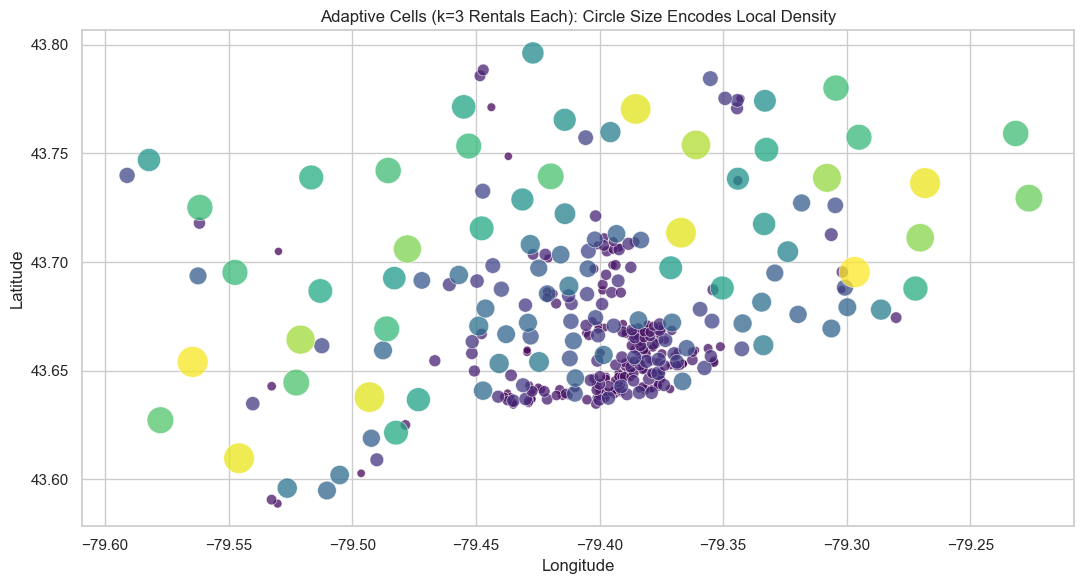

In [147]:
plt.figure(figsize=(11, 6))
plot_df = adaptive_grid.copy()

# Radius is the key density signal: sparse areas -> larger circles.
sns.scatterplot(
    data=plot_df,
    x='centroid_lon',
    y='centroid_lat',
    size='radius_m',
    hue='radius_m',
    palette='viridis',
    sizes=(30, 500),
    alpha=0.75,
    legend=False,
)

plt.title(f'Adaptive Cells (k={K_RENTALS_PER_CELL} Rentals Each): Circle Size Encodes Local Density')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

In [148]:
map_sample = adaptive_grid.sample(min(4000, len(adaptive_grid)), random_state=42)
fig = px.scatter_mapbox(
    map_sample,
    lat='centroid_lat',
    lon='centroid_lon',
    color='radius_m',
    size='radius_m',
    hover_data={
        'adaptive_cell_id': True,
        'rental_count': True,
        'radius_m': ':.1f',
        'crime_count_in_circle': True,
        'restaurant_count_in_circle': True,
        'subway_count_in_circle': True,
    },
    title=f'Adaptive Sparse Grid: Exactly {K_RENTALS_PER_CELL} Rentals Per Cell (Radius reflects density)',
    color_continuous_scale='Turbo',
    zoom=9.2,
    height=580,
)
fig.update_layout(mapbox_style='carto-positron', margin={'l': 0, 'r': 0, 't': 40, 'b': 0})
fig.show()

## Validation Checks

**Question:** Did preprocessing and sparse-grid creation complete with integrity?

**Method:** Assertions on coordinate validity, projected coordinates, point assignment completeness, and artifact existence.

**What we found:** Checks below must pass for this notebook execution to be valid.

**Why this matters for next-phase clustering:** It guarantees the grid foundation is technically sound before unsupervised modeling.


In [149]:
# coordinate validity after cleaning
assert valid_coord_mask(crime, 'Lat', 'Long').all()
assert valid_coord_mask(rent, 'Lat', 'Long').all()
assert valid_coord_mask(rest_venue, 'Restaurant Latitude', 'Restaurant Longitude').all()
assert valid_coord_mask(subway, 'latitude', 'longitude').all()

# projected coordinates must exist and be finite
for df in [crime_proj, rent_proj, rest_proj, subway_proj]:
    assert df[['x_m', 'y_m']].notna().all().all()
    assert np.isfinite(df[['x_m', 'y_m']].to_numpy()).all()

# adaptive-cell integrity
assert len(adaptive_grid) > 0
assert (adaptive_grid['rental_count'] == K_RENTALS_PER_CELL).all()
assert adaptive_grid[['radius_m', 'cell_area_km2']].gt(0).all().all()

# retained rental points consistency
expected_retained = len(rent_core) - len(leftover_rental_indices)
assert int(adaptive_grid['rental_count'].sum()) == int(expected_retained)


# non-overlap assignment integrity (each point counted once)
assert int(adaptive_grid['crime_count_in_circle'].sum()) == int(len(crime_proj))
assert int(adaptive_grid['restaurant_count_in_circle'].sum()) == int(len(rest_proj))
assert int(adaptive_grid['subway_count_in_circle'].sum()) == int(len(subway_proj))

# outputs
assert (OUTPUT_DIR / 'data_quality_audit.csv').exists()
assert (OUTPUT_DIR / 'preprocessing_drop_log.csv').exists()
assert adaptive_output.exists() and adaptive_output.stat().st_size > 0

validation = pd.DataFrame([
    {'check': 'rental_points_total', 'value': int(len(rent_core)), 'status': 'pass'},
    {'check': 'adaptive_cells_created', 'value': int(len(adaptive_grid)), 'status': 'pass'},
    {'check': 'rentals_per_cell_min', 'value': int(adaptive_grid['rental_count'].min()), 'status': 'pass'},
    {'check': 'rentals_per_cell_max', 'value': int(adaptive_grid['rental_count'].max()), 'status': 'pass'},
    {'check': 'leftover_rentals', 'value': int(len(leftover_rental_indices)), 'status': 'pass'},
    {'check': 'crime_count_no_overlap', 'value': int(adaptive_grid['crime_count_in_circle'].sum()), 'status': 'pass'},
    {'check': 'restaurant_count_no_overlap', 'value': int(adaptive_grid['restaurant_count_in_circle'].sum()), 'status': 'pass'},
    {'check': 'subway_count_no_overlap', 'value': int(adaptive_grid['subway_count_in_circle'].sum()), 'status': 'pass'},
])

validation

,check,value,status
0,rental_points_total,1191,pass
1,adaptive_cells_created,394,pass
2,rentals_per_cell_min,3,pass
3,rentals_per_cell_max,3,pass
4,leftover_rentals,9,pass
5,crime_count_no_overlap,178892,pass
6,restaurant_count_no_overlap,6101,pass
7,subway_count_no_overlap,69,pass


## Phase 2 Handoff Notes

This notebook intentionally stops at adaptive spatial-unit construction.

Next phase should:
1. aggregate richer engineered features per adaptive cell,
2. normalize/transform features,
3. run clustering,
4. evaluate overlap/separation and spatial coherence.


In [150]:
elapsed_minutes = (time.time() - NOTEBOOK_START) / 60
print(f'Notebook runtime: {elapsed_minutes:.2f} minutes')
print('Saved artifacts:')
for p in sorted(OUTPUT_DIR.glob('*.csv')):
    print(' -', p)


Notebook runtime: 0.20 minutes
Saved artifacts:
 - ..\outputs\eda\adaptive_feature_engineered_k3.csv
 - ..\outputs\eda\adaptive_feature_matrix_scaled_k3.csv
 - ..\outputs\eda\adaptive_feature_rows_k3.csv
 - ..\outputs\eda\adaptive_sparse_grid_rentals_k3.csv
 - ..\outputs\eda\adaptive_sparse_grid_rentals_k5.csv
 - ..\outputs\eda\causal_rent_treatment_ranking.csv
 - ..\outputs\eda\causal_rent_treatment_ranking_absolute.csv
 - ..\outputs\eda\data_quality_audit.csv
 - ..\outputs\eda\neighbourhood_preprocessed_features.csv
 - ..\outputs\eda\preprocessing_drop_log.csv
 - ..\outputs\eda\sparse_spatial_grid_500m.csv


## Step 3: Feature Engineering for Clustering

This section creates clustering-ready features focused on neighbourhood profile insights (not location encoding):
- Density and ratio features (per-km2 and amenity/safety balance)
- One-hot encoding for tier columns (rent, safety, transit, food access)
- Frequency encoding for tier combinations to capture how common each profile is


### Why These Features Are Relevant Here

The goal is to understand neighbourhood profiles across rent, safety, transit, and food access tiers. So the encoding strategy is designed to make those tier patterns explicit and comparable.

- Density features (per_km2) normalize counts across variable-size adaptive cells.
- Ratio features expose trade-offs (for example amenities relative to crime) that raw counts can hide.
- Log features reduce the influence of extreme count hotspots.
- One-hot tier features make each tier directly interpretable in cluster profiles.
- Combo-frequency features represent how common or rare each tier combination is, which helps surface emerging vs typical profiles.
- Spatial/index IDs are kept for traceability only, not as encoding targets.


#### 1) Numeric Density, Ratio, and Log Features
Why this matters:
- crime_per_km2, restaurant_per_km2, subway_per_km2: comparable intensity across variable-size adaptive cells.
- amenity_to_crime_ratio, subway_to_crime_ratio: how much convenience exists relative to safety pressure.
- rent_to_amenity_ratio: affordability context against local offerings.
- log1p features: compresses extreme tails common in urban count data while preserving ordering.


In [151]:
fe = adaptive_grid.copy()
eps = 1e-6

fe['crime_per_km2'] = fe['crime_count_in_circle'] / (fe['cell_area_km2'] + eps)
fe['violent_crime_per_km2'] = fe['violent_crime_count_in_circle'] / (fe['cell_area_km2'] + eps)
fe['restaurant_per_km2'] = fe['restaurant_count_in_circle'] / (fe['cell_area_km2'] + eps)
fe['subway_per_km2'] = fe['subway_count_in_circle'] / (fe['cell_area_km2'] + eps)

fe['amenity_to_crime_ratio'] = fe['restaurant_count_in_circle'] / (fe['crime_count_in_circle'] + 1.0)
fe['subway_to_crime_ratio'] = fe['subway_count_in_circle'] / (fe['crime_count_in_circle'] + 1.0)
fe['rent_to_amenity_ratio'] = fe['mean_rent'] / (fe['restaurant_count_in_circle'] + 1.0)

for col in ['crime_count_in_circle', 'violent_crime_count_in_circle', 'restaurant_count_in_circle', 'subway_count_in_circle', 'radius_m', 'mean_rent', 'mean_price_per_bedroom']:
    fe[f'{col}_log1p'] = np.log1p(fe[col].clip(lower=0))

fe[['crime_per_km2', 'restaurant_per_km2', 'amenity_to_crime_ratio']].head(5)


,crime_per_km2,restaurant_per_km2,amenity_to_crime_ratio
0,28892.193961,3399.081642,0.116505
1,289488.278352,9813.161978,0.033803
2,24773.715957,599.364096,0.024000
3,0.000000,0.000000,0.000000
4,97028.815949,15016.364373,0.152941


#### 2) One-Hot Encoding for Low-Cardinality Tiers
Why this matters:
- rent_tier describes market level (lower to premium).
- safety_tier turns violent-crime ratio into interpretable risk bands.
- transit_tier and food_access_tier summarize access level instead of raw counts.
- One-hot keeps categories model-ready and avoids imposing fake numeric distance between labels.


In [152]:

# where rent_q1 is the lowest rent quartile and rent_q4 is the highest
fe['rent_tier'] = pd.qcut(fe['mean_rent'], q=4, labels=['rent_q1', 'rent_q2', 'rent_q3', 'rent_q4'], duplicates='drop')

# where safe <10% violent crime, moderate 10-25%, higher_risk >25%
# -0.01 was used just to ensure that 0% violent crime cases are included in the 'safe' tier
fe['safety_tier'] = pd.cut(fe['violent_crime_ratio_in_circle'], bins=[-0.01, 0.10, 0.25, 1.0], labels=['safe', 'moderate', 'higher_risk'])


fe['transit_tier'] = pd.cut(fe['subway_count_in_circle'], bins=[-0.01, 0.5, 1.5, 3.5, np.inf], labels=['none', 'low', 'medium', 'high'])

# where food_q1 is the lowest food access quartile and food_q4 is the highest
fe['food_access_tier'] = pd.qcut(fe['restaurant_count_in_circle'], q=4, labels=['food_q1', 'food_q2', 'food_q3', 'food_q4'], duplicates='drop')

low_card_cols = ['rent_tier', 'safety_tier', 'transit_tier', 'food_access_tier']
for c in low_card_cols:
    fe[c] = fe[c].astype('object').fillna('missing')

one_hot = pd.get_dummies(fe[low_card_cols], prefix=low_card_cols, dtype=int)
one_hot.head(5)


,rent_tier_rent_q1,rent_tier_rent_q2,rent_tier_rent_q3,rent_tier_rent_q4,safety_tier_higher_risk,safety_tier_moderate,safety_tier_safe,transit_tier_low,transit_tier_medium,transit_tier_none,food_access_tier_food_q1,food_access_tier_food_q2,food_access_tier_food_q3,food_access_tier_food_q4
0,0,1,0,0,1,0,0,0,0,1,0,0,1,0
1,1,0,0,0,1,0,0,0,0,1,0,0,1,0
2,1,0,0,0,1,0,0,0,0,1,0,1,0,0
3,1,0,0,0,0,0,1,0,0,1,1,0,0,0
4,0,0,1,0,1,0,0,0,0,1,0,0,1,0


#### 3) Frequency Encoding for Tier Combinations
Why this matters:
- Individual tiers are informative, but combinations (for example high transit + moderate safety) often define the actual neighbourhood profile.
- Frequency encoding on combinations captures how common each profile is across the city.
- This keeps the encoding compact and aligned with our insight goal.


In [153]:
tier_cols = ['rent_tier', 'safety_tier', 'transit_tier', 'food_access_tier']

combo_defs = {
    'rent_safety_combo': ['rent_tier', 'safety_tier'],
    'transit_food_combo': ['transit_tier', 'food_access_tier'],
    'rent_transit_combo': ['rent_tier', 'transit_tier'],
    'safety_transit_combo': ['safety_tier', 'transit_tier'],
    'all_tiers_combo': tier_cols,
}

tier_combo_freq = pd.DataFrame(index=fe.index)
for combo_name, cols in combo_defs.items():
    combo_key = fe[cols].astype(str).agg('|'.join, axis=1)
    combo_map = combo_key.value_counts(normalize=True)
    tier_combo_freq[f'{combo_name}_freq'] = combo_key.map(combo_map).astype(float)

fe = pd.concat([fe, tier_combo_freq], axis=1)
fe[[c for c in fe.columns if c.endswith('_combo_freq')]].head(5)


,rent_safety_combo_freq,transit_food_combo_freq,rent_transit_combo_freq,safety_transit_combo_freq,all_tiers_combo_freq
0,0.215736,0.197970,0.210660,0.713198,0.063452
1,0.220812,0.197970,0.220812,0.713198,0.038071
2,0.220812,0.248731,0.220812,0.713198,0.055838
3,0.025381,0.258883,0.220812,0.126904,0.025381
4,0.210660,0.197970,0.213198,0.713198,0.050761


#### 4) Build Final Feature Matrix (Pre-Scaling)
Why this matters:
- This step assembles engineered numeric features, one-hot tier columns, and combo-frequency columns in one model-ready table.
- We remove identifier and coordinate fields used for joins/traceability so clustering focuses on behavioural profile features.
- Scaling is done in the next dedicated section so the fitted scaler can be reused in the app.


In [154]:
drop_from_features = {
    'adaptive_cell_id', 'member_rental_idx', 'seed_grid_x', 'seed_grid_y',
    'spatial_key_1km', 'centroid_lon', 'centroid_lat', 'x_centroid', 'y_centroid'
}

numeric_candidates = [c for c in fe.columns if c not in drop_from_features and pd.api.types.is_numeric_dtype(fe[c])]
numeric_features = fe[numeric_candidates].replace([np.inf, -np.inf], np.nan).fillna(0.0)

feature_matrix = pd.concat([numeric_features, one_hot], axis=1)
feature_matrix = feature_matrix.loc[:, ~feature_matrix.columns.duplicated()].copy()

feature_output = OUTPUT_DIR / f'adaptive_feature_engineered_k{K_RENTALS_PER_CELL}.csv'
feature_row_output = OUTPUT_DIR / f'adaptive_feature_rows_k{K_RENTALS_PER_CELL}.csv'

feature_matrix.to_csv(feature_output, index=False)
fe.to_csv(feature_row_output, index=False)

print('Feature matrix prepared (not scaled yet).')
print(f'Rows: {len(feature_matrix):,} | Features: {feature_matrix.shape[1]:,}')
print('Saved:')
print(' -', feature_output)
print(' -', feature_row_output)
feature_matrix.head(5)


Feature matrix prepared (not scaled yet).
Rows: 394 | Features: 49
Saved:
 - ..\outputs\eda\adaptive_feature_engineered_k3.csv
 - ..\outputs\eda\adaptive_feature_rows_k3.csv


,rental_count,growth_rings,seed_local_k_radius_m,radius_m,mean_rent,median_rent,mean_price_per_bedroom,cell_area_km2,crime_count_in_circle,violent_crime_count_in_circle,violent_crime_ratio_in_circle,restaurant_count_in_circle,subway_count_in_circle,crime_assignment_median_dist_m,restaurant_assignment_median_dist_m,subway_assignment_median_dist_m,crime_per_km2,violent_crime_per_km2,restaurant_per_km2,subway_per_km2,amenity_to_crime_ratio,subway_to_crime_ratio,rent_to_amenity_ratio,crime_count_in_circle_log1p,violent_crime_count_in_circle_log1p,restaurant_count_in_circle_log1p,subway_count_in_circle_log1p,radius_m_log1p,mean_rent_log1p,mean_price_per_bedroom_log1p,rent_safety_combo_freq,transit_food_combo_freq,rent_transit_combo_freq,safety_transit_combo_freq,all_tiers_combo_freq,rent_tier_rent_q1,rent_tier_rent_q2,rent_tier_rent_q3,rent_tier_rent_q4,safety_tier_higher_risk,safety_tier_moderate,safety_tier_safe,transit_tier_low,transit_tier_medium,transit_tier_none,food_access_tier_food_q1,food_access_tier_food_q2,food_access_tier_food_q3,food_access_tier_food_q4
0,3,0,33.517635,33.517635,2150.000000,2100.0,1733.333333,0.003529,102,70,0.686275,12,0,673.752858,290.340158,394.397596,28892.193961,19827.976248,3399.081642,0.0,0.116505,0.0,165.384615,4.634729,4.262680,2.564949,0.0,3.541470,7.673688,7.458378,0.215736,0.197970,0.210660,0.713198,0.063452,0,1,0,0,1,0,0,0,0,1,0,0,1,0
1,3,0,19.721210,19.721210,1983.333333,2000.0,1983.333333,0.001222,354,238,0.672316,12,0,673.752858,290.340158,394.397596,289488.278352,194627.712564,9813.161978,0.0,0.033803,0.0,152.564103,5.872118,5.476464,2.564949,0.0,3.031158,7.593038,7.593038,0.220812,0.197970,0.220812,0.713198,0.038071,1,0,0,0,1,0,0,0,0,1,0,0,1,0
2,3,0,39.911398,39.911398,2033.333333,2050.0,2033.333333,0.005004,124,77,0.620968,3,0,673.752858,290.340158,394.397596,24773.715957,15383.678457,599.364096,0.0,0.024000,0.0,508.333333,4.828314,4.356709,1.386294,0.0,3.711409,7.617923,7.617923,0.220812,0.248731,0.220812,0.713198,0.055838,1,0,0,0,1,0,0,0,0,1,0,1,0,0
3,3,0,33.517635,33.517635,2113.333333,2100.0,2113.333333,0.003529,0,0,0.000000,0,0,673.752858,290.340158,394.397596,0.000000,0.000000,0.000000,0.0,0.000000,0.0,2113.333333,0.000000,0.000000,0.000000,0.0,3.541470,7.656495,7.656495,0.025381,0.258883,0.220812,0.126904,0.025381,1,0,0,0,0,0,1,0,0,1,1,0,0,0
4,3,0,16.590649,16.590649,2483.333333,2550.0,2483.333333,0.000865,84,78,0.928571,13,0,673.752858,290.340158,394.397596,97028.815949,90098.186239,15016.364373,0.0,0.152941,0.0,177.380952,4.442651,4.369448,2.639057,0.0,2.867367,7.817760,7.817760,0.210660,0.197970,0.213198,0.713198,0.050761,0,0,1,0,1,0,0,0,0,1,0,0,1,0


#### 5) Scale Features with StandardScaler and Save Scaler for App
Why StandardScaler specifically:
- StandardScaler applies z-score normalization: each feature becomes (value - mean) / std.
- This centers features around 0 and gives them unit variance, so rent, density, ratios, and encoded columns are on a comparable scale.

Why scaling is important for this notebook:
- Our next step is clustering, and common clustering methods (especially KMeans and distance-based approaches) use Euclidean distance.
- Without scaling, large-magnitude variables (for example rent) dominate distance calculations and can hide safety/accessibility signals.
- With scaling, clusters reflect multi-factor neighbourhood profiles instead of mainly whichever feature has the largest numeric range.

Why saving the fitted scaler matters for the app:
- The app must transform incoming data with the exact same means/stds used during analysis/training.
- Re-fitting a new scaler in production would shift feature space and make cluster assignments inconsistent with notebook results.


In [155]:
from sklearn.preprocessing import StandardScaler
import joblib

scaler = StandardScaler()
feature_matrix_scaled = pd.DataFrame(
    scaler.fit_transform(feature_matrix),
    columns=feature_matrix.columns,
    index=feature_matrix.index,
)

scaled_output = OUTPUT_DIR / f'adaptive_feature_matrix_scaled_k{K_RENTALS_PER_CELL}.csv'
app_artifact_dir = OUTPUT_DIR.parent / 'app'
app_artifact_dir.mkdir(parents=True, exist_ok=True)
scaler_output = app_artifact_dir / f'adaptive_standard_scaler_k{K_RENTALS_PER_CELL}.joblib'

feature_matrix_scaled.to_csv(scaled_output, index=False)
joblib.dump(scaler, scaler_output)

print('Scaling complete.')
print('Saved:')
print(' -', scaled_output)
print(' -', scaler_output)
feature_matrix_scaled.head(5)


Scaling complete.
Saved:
 - ..\outputs\eda\adaptive_feature_matrix_scaled_k3.csv
 - ..\outputs\app\adaptive_standard_scaler_k3.joblib


,rental_count,growth_rings,seed_local_k_radius_m,radius_m,mean_rent,median_rent,mean_price_per_bedroom,cell_area_km2,crime_count_in_circle,violent_crime_count_in_circle,violent_crime_ratio_in_circle,restaurant_count_in_circle,subway_count_in_circle,crime_assignment_median_dist_m,restaurant_assignment_median_dist_m,subway_assignment_median_dist_m,crime_per_km2,violent_crime_per_km2,restaurant_per_km2,subway_per_km2,amenity_to_crime_ratio,subway_to_crime_ratio,rent_to_amenity_ratio,crime_count_in_circle_log1p,violent_crime_count_in_circle_log1p,restaurant_count_in_circle_log1p,subway_count_in_circle_log1p,radius_m_log1p,mean_rent_log1p,mean_price_per_bedroom_log1p,rent_safety_combo_freq,transit_food_combo_freq,rent_transit_combo_freq,safety_transit_combo_freq,all_tiers_combo_freq,rent_tier_rent_q1,rent_tier_rent_q2,rent_tier_rent_q3,rent_tier_rent_q4,safety_tier_higher_risk,safety_tier_moderate,safety_tier_safe,transit_tier_low,transit_tier_medium,transit_tier_none,food_access_tier_food_q1,food_access_tier_food_q2,food_access_tier_food_q3,food_access_tier_food_q4
0,0.0,-0.722472,-0.678711,-0.678711,-0.529829,-0.499411,-0.530271,-0.418612,-0.349074,-0.311259,0.682674,-0.156900,-0.360624,1.136868e-13,0.0,-5.684342e-14,-0.006454,-0.005031,0.508222,-0.14159,-0.036668,-0.061048,-0.620646,-0.079374,-0.034328,0.400394,-0.383889,-1.199235,-0.465018,-0.448610,0.474211,0.002433,0.320076,0.632501,1.278994,-0.579304,1.737932,-0.575396,-0.579304,0.423840,-0.152894,-0.385601,-0.345425,-0.177239,0.398527,-0.610592,-0.591029,1.837873,-0.563672
1,0.0,-0.722472,-0.700972,-0.700972,-0.920912,-0.722310,0.153867,-0.419134,-0.099198,-0.057614,0.625253,-0.156900,-0.360624,1.136868e-13,0.0,-5.684342e-14,1.279231,1.218375,1.912766,-0.14159,-0.111777,-0.061048,-0.634583,0.495026,0.565688,0.400394,-0.383889,-1.562209,-0.912697,0.242284,0.550910,0.002433,0.472659,0.632501,-0.079291,1.726209,-0.575396,-0.575396,-0.579304,0.423840,-0.152894,-0.385601,-0.345425,-0.177239,0.398527,-0.610592,-0.591029,1.837873,-0.563672
2,0.0,-0.722472,-0.668394,-0.668394,-0.803587,-0.610860,0.290695,-0.418279,-0.327260,-0.300691,0.414015,-0.562120,-0.360624,1.136868e-13,0.0,-5.684342e-14,-0.026773,-0.036137,-0.104855,-0.14159,-0.120679,-0.061048,-0.247826,0.010489,0.012154,-0.465510,-0.383889,-1.078361,-0.774562,0.369961,0.550910,0.687253,0.472659,0.632501,0.871509,1.726209,-0.575396,-0.575396,-0.579304,0.423840,-0.152894,-0.385601,-0.345425,-0.177239,0.398527,-0.610592,1.691965,-0.544107,-0.563672
3,0.0,-0.722472,-0.678711,-0.678711,-0.615868,-0.499411,0.509619,-0.418612,-0.450215,-0.416945,-2.140521,-0.697194,-0.360624,1.136868e-13,0.0,-5.684342e-14,-0.148997,-0.143805,-0.236103,-0.14159,-0.142476,-0.061048,1.496970,-2.230831,-2.141518,-1.483958,-0.383889,-1.199235,-0.560456,0.567858,-2.402008,0.824217,0.472659,-1.472614,-0.758433,1.726209,-0.575396,-0.575396,-0.579304,-2.359378,-0.152894,2.593355,-0.345425,-0.177239,0.398527,1.637755,-0.591029,-0.544107,-0.563672
4,0.0,-0.722472,-0.706023,-0.706023,0.252336,0.503636,1.522143,-0.419215,-0.366922,-0.299181,1.679435,-0.111876,-0.360624,1.136868e-13,0.0,-5.684342e-14,0.329707,0.486783,3.052155,-0.14159,-0.003577,-0.061048,-0.607605,-0.168537,0.018452,0.454838,-0.383889,-1.678710,0.334706,1.395253,0.397512,0.002433,0.358222,0.632501,0.599852,-0.579304,-0.575396,1.737932,-0.579304,0.423840,-0.152894,-0.385601,-0.345425,-0.177239,0.398527,-0.610592,-0.591029,1.837873,-0.563672


## Step 3: Multi-Treatment Causal Ranking for Rent

This section estimates rent impact across multiple candidate treatments to determine which neighborhood feature has the strongest causal lift on rent.

Approach:
- Build one binary treatment at a time (high vs low exposure).
- Re-screen confounders per treatment using `|SMD| x |corr(outcome)|`.
- Estimate ATE with both S-learner (LR) and T-learner (XGBoost).
- Rank by XGBoost ATE (primary) and compare LR as a robustness check.



In [170]:
# Candidate treatments (high vs low)
# Positive ATE means: higher exposure to that feature increases rent (treated - control).
treatment_specs = [
    {'name': 'high_transit_access', 'var': 'subway_count_in_circle', 'rule': 'positive'},
    {'name': 'high_food_access', 'var': 'restaurant_count_in_circle', 'rule': 'median'},
    {'name': 'high_crime', 'var': 'crime_count_in_circle', 'rule': 'median'},
    {'name': 'high_violent_crime_ratio', 'var': 'violent_crime_ratio_in_circle', 'rule': 'q75'},
    {'name': 'large_service_radius', 'var': 'radius_m', 'rule': 'median'},
]

confounder_pool = [
    'cell_area_km2',
    'radius_m',
    'crime_count_in_circle',
    'violent_crime_count_in_circle',
    'violent_crime_ratio_in_circle',
    'restaurant_count_in_circle',
    'subway_count_in_circle',
]

# Local causal estimator helper
try:
    from causalml.inference.meta import LRSRegressor, XGBTRegressor
    _CAUSALML_AVAILABLE_STEP4 = True
except Exception:
    _CAUSALML_AVAILABLE_STEP4 = False

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


def _ci_from_effects_step4(effects: np.ndarray, z: float = 1.96):
    effects = np.asarray(effects, dtype=float)
    mean = float(np.mean(effects))
    se = float(np.std(effects, ddof=1) / np.sqrt(len(effects))) if len(effects) > 1 else 0.0
    return mean, mean - z * se, mean + z * se


def estimate_ate_cate_pair(X: pd.DataFrame, T: np.ndarray, Y: np.ndarray):
    X_df = pd.DataFrame(X).copy()
    T_arr = np.asarray(T, dtype=int)
    Y_arr = np.asarray(Y, dtype=float)

    if _CAUSALML_AVAILABLE_STEP4:
        lr_s = LRSRegressor()
        ate_lr, lb_lr, ub_lr = lr_s.estimate_ate(X=X_df, treatment=T_arr, y=Y_arr)
        cate_lr = lr_s.fit_predict(X=X_df, treatment=T_arr, y=Y_arr)

        xgb_t = XGBTRegressor(random_state=42, n_estimators=200, max_depth=4, learning_rate=0.05)
        ate_xgb, lb_xgb, ub_xgb = xgb_t.estimate_ate(X=X_df, treatment=T_arr, y=Y_arr)
        cate_xgb = xgb_t.fit_predict(X=X_df, treatment=T_arr, y=Y_arr)

        return {
            'ATE_LR': float(ate_lr[0]), 'ATE_LR_CI_low': float(lb_lr[0]), 'ATE_LR_CI_high': float(ub_lr[0]),
            'ATE_XGB': float(ate_xgb[0]), 'ATE_XGB_CI_low': float(lb_xgb[0]), 'ATE_XGB_CI_high': float(ub_xgb[0]),
            'CATE_LR': np.asarray(cate_lr, dtype=float), 'CATE_XGB': np.asarray(cate_xgb, dtype=float),
            'engine': 'causalml'
        }

    X_num = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    Xs = X_num.copy()
    Xs['T'] = T_arr
    s_model = LinearRegression()
    s_model.fit(Xs, Y_arr)

    X1 = X_num.copy(); X1['T'] = 1
    X0 = X_num.copy(); X0['T'] = 0
    cate_lr = s_model.predict(X1) - s_model.predict(X0)
    ate_lr, lb_lr, ub_lr = _ci_from_effects_step4(cate_lr)

    Xt = X_num[T_arr == 1]
    Xc = X_num[T_arr == 0]
    Yt = Y_arr[T_arr == 1]
    Yc = Y_arr[T_arr == 0]

    model_t = XGBRegressor(random_state=42, n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9)
    model_c = XGBRegressor(random_state=42, n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9)

    model_t.fit(Xt, Yt)
    model_c.fit(Xc, Yc)

    cate_xgb = model_t.predict(X_num) - model_c.predict(X_num)
    ate_xgb, lb_xgb, ub_xgb = _ci_from_effects_step4(cate_xgb)

    return {
        'ATE_LR': ate_lr, 'ATE_LR_CI_low': lb_lr, 'ATE_LR_CI_high': ub_lr,
        'ATE_XGB': ate_xgb, 'ATE_XGB_CI_low': lb_xgb, 'ATE_XGB_CI_high': ub_xgb,
        'CATE_LR': np.asarray(cate_lr, dtype=float), 'CATE_XGB': np.asarray(cate_xgb, dtype=float),
        'engine': 'fallback_s_t_learners'
    }


def make_treatment(series: pd.Series, rule: str):
    s = pd.to_numeric(series, errors='coerce')
    if rule == 'median':
        thr = s.median()
        t = (s >= thr).astype(int)
    elif rule == 'q75':
        thr = s.quantile(0.75)
        t = (s >= thr).astype(int)
    elif rule == 'positive':
        thr = 0.0
        t = (s > 0).astype(int)
    else:
        raise ValueError(f'Unknown rule: {rule}')
    return t, float(thr)

print('Step 3 engine:', 'CausalML' if _CAUSALML_AVAILABLE_STEP4 else 'Fallback S/T learners')



Step 3 engine: CausalML


In [157]:
ranking_rows = []

for spec in treatment_specs:
    name, t_var, rule = spec['name'], spec['var'], spec['rule']

    use_cols = ['mean_rent', t_var] + [c for c in confounder_pool if c != t_var]
    use_cols = [c for c in use_cols if c in fe.columns]

    d = fe[use_cols].copy()
    d['mean_rent'] = pd.to_numeric(d['mean_rent'], errors='coerce')
    d = d.dropna(subset=['mean_rent', t_var]).copy()

    d['T'], threshold = make_treatment(d[t_var], rule)

    treated_n = int((d['T'] == 1).sum())
    control_n = int((d['T'] == 0).sum())
    if treated_n < 30 or control_n < 30:
        print(f'Skipping {name}: too few samples (treated={treated_n}, control={control_n})')
        continue

    sensitivity_rows = []
    for c in [x for x in confounder_pool if x != t_var and x in d.columns]:
        t = pd.to_numeric(d.loc[d['T'] == 1, c], errors='coerce')
        k = pd.to_numeric(d.loc[d['T'] == 0, c], errors='coerce')

        pooled_std = np.sqrt((t.var(ddof=1) + k.var(ddof=1)) / 2)
        smd = (t.mean() - k.mean()) / pooled_std if pooled_std and not np.isnan(pooled_std) else 0.0
        corr = d[[c, 'mean_rent']].corr().iloc[0, 1]

        sensitivity_rows.append({
            'var': c,
            'score': abs(float(smd)) * (abs(float(corr)) if pd.notna(corr) else 0.0),
        })

    sens = pd.DataFrame(sensitivity_rows).sort_values('score', ascending=False)
    selected = sens.head(min(5, len(sens)))['var'].tolist()

    X = d[selected].replace([np.inf, -np.inf], np.nan).fillna(0.0)
    Y = d['mean_rent'].values
    T = d['T'].values

    effects = estimate_ate_cate_pair(X=X, T=T, Y=Y)

    ranking_rows.append({
        'treatment': name,
        'treatment_variable': t_var,
        'threshold_rule': rule,
        'threshold_value': threshold,
        'treated_n': treated_n,
        'control_n': control_n,
        'treated_share': float(np.mean(T)),
        'ATE_LR': effects['ATE_LR'],
        'ATE_LR_CI_low': effects['ATE_LR_CI_low'],
        'ATE_LR_CI_high': effects['ATE_LR_CI_high'],
        'ATE_XGB': effects['ATE_XGB'],
        'ATE_XGB_CI_low': effects['ATE_XGB_CI_low'],
        'ATE_XGB_CI_high': effects['ATE_XGB_CI_high'],
        'selected_confounders': ', '.join(selected),
        'engine': effects['engine'],
    })

ranking_df = pd.DataFrame(ranking_rows).sort_values('ATE_XGB', ascending=False).reset_index(drop=True)
ranking_output = OUTPUT_DIR / 'causal_rent_treatment_ranking.csv'
ranking_df.to_csv(ranking_output, index=False)

print('Causal ranking across treatments (sorted by ATE_XGB):')
display(ranking_df)
print('Saved:', ranking_output)



Causal ranking across treatments (sorted by ATE_XGB):


,treatment,treatment_variable,threshold_rule,threshold_value,treated_n,control_n,treated_share,ATE_LR,ATE_LR_CI_low,ATE_LR_CI_high,ATE_XGB,ATE_XGB_CI_low,ATE_XGB_CI_high,selected_confounders,engine
0,high_transit_access,subway_count_in_circle,positive,0.000000,54,340,0.137056,67.961392,-87.115275,223.038059,93.055668,44.815814,141.295521,"violent_crime_ratio_in_circle, restaurant_coun...",causalml
1,high_food_access,restaurant_count_in_circle,median,9.000000,198,196,0.502538,-45.884446,-138.631584,46.862692,-30.139113,-81.348488,21.070262,"violent_crime_ratio_in_circle, cell_area_km2, ...",causalml
2,high_violent_crime_ratio,violent_crime_ratio_in_circle,q75,0.672709,99,295,0.251269,-28.159774,-137.522332,81.202784,-36.887765,-85.103823,11.328294,"radius_m, cell_area_km2, restaurant_count_in_c...",causalml
3,large_service_radius,radius_m,median,169.753423,197,197,0.500000,6.710245,-87.977264,101.397755,-48.495286,-98.799818,1.809245,"cell_area_km2, restaurant_count_in_circle, vio...",causalml
4,high_crime,crime_count_in_circle,median,189.000000,197,197,0.500000,-136.675469,-244.060491,-29.290447,-277.227262,-335.824867,-218.629657,"violent_crime_ratio_in_circle, restaurant_coun...",causalml


Saved: ..\outputs\eda\causal_rent_treatment_ranking.csv


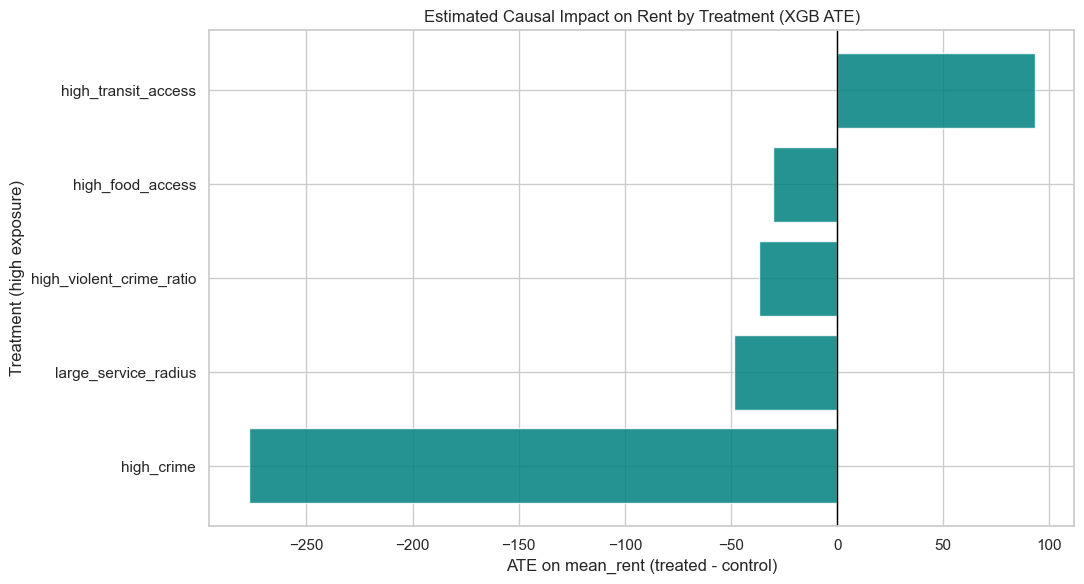

Top estimated rent-increasing driver (by XGB ATE):
- high_transit_access (subway_count_in_circle) with ATE_XGB=93.06


In [158]:
if not ranking_df.empty:
    plt.figure(figsize=(11, 6))
    plot_df = ranking_df.sort_values('ATE_XGB', ascending=True)
    plt.barh(plot_df['treatment'], plot_df['ATE_XGB'], color='teal', alpha=0.85)
    plt.axvline(0, color='black', linewidth=1)
    plt.title('Estimated Causal Impact on Rent by Treatment (XGB ATE)')
    plt.xlabel('ATE on mean_rent (treated - control)')
    plt.ylabel('Treatment (high exposure)')
    plt.tight_layout()
    plt.show()

    top = ranking_df.iloc[0]
    print('Top estimated rent-increasing driver (by XGB ATE):')
    print('- {} ({}) with ATE_XGB={:.2f}'.format(top['treatment'], top['treatment_variable'], top['ATE_XGB']))
else:
    print('No valid treatment comparison produced. Check sample sizes and missing data.')


## Results
- high_crime has the largest absolute effect, but it is negative (ATE < 0), meaning higher crimeis estimated to decrease rent.
- high_transit_access is the largest positive effect (ATE > 0), so it is the top rent-increasing driver.

In other words, 
1. Top rent-increasing driver: high_transit_access
2. Strongest rent-decreasing driver: high_crime
3. Strongest overall impact (by absolute value): high_crime

## Step 4: Causal Deep Dive for Rent (Transit Access as Treatment)

**Question:** What is the causal effect of higher transit access on rent after controlling for confounders?

**Method:** Following the causal notebook and PDF framework, define a binary treatment, screen confounders with SMD+correlation, then estimate ATE/CATE using CausalML S- and T-learners.



In [159]:
# Optional install if causalml is not available in the environment
%pip install causalml xgboost lightgbm


Note: you may need to restart the kernel to use updated packages.


In [160]:
try:
    from causalml.inference.meta import LRSRegressor, XGBTRegressor
    CAUSALML_AVAILABLE = True
except Exception:
    CAUSALML_AVAILABLE = False

from sklearn.linear_model import LinearRegression
from xgboost import XGBRegressor


def _ci_from_effects(effects: np.ndarray, z: float = 1.96):
    effects = np.asarray(effects, dtype=float)
    mean = float(np.mean(effects))
    se = float(np.std(effects, ddof=1) / np.sqrt(len(effects))) if len(effects) > 1 else 0.0
    return mean, mean - z * se, mean + z * se


def estimate_ate_cate_pair(X: pd.DataFrame, T: np.ndarray, Y: np.ndarray):
    # Return ATE/CI/CATE for LR S-learner and XGB T-learner, using CausalML when available.
    X_df = pd.DataFrame(X).copy()
    T_arr = np.asarray(T, dtype=int)
    Y_arr = np.asarray(Y, dtype=float)

    if CAUSALML_AVAILABLE:
        lr_s = LRSRegressor()
        ate_lr, lb_lr, ub_lr = lr_s.estimate_ate(X=X_df, treatment=T_arr, y=Y_arr)
        cate_lr = lr_s.fit_predict(X=X_df, treatment=T_arr, y=Y_arr)

        xgb_t = XGBTRegressor(random_state=42, n_estimators=200, max_depth=4, learning_rate=0.05)
        ate_xgb, lb_xgb, ub_xgb = xgb_t.estimate_ate(X=X_df, treatment=T_arr, y=Y_arr)
        cate_xgb = xgb_t.fit_predict(X=X_df, treatment=T_arr, y=Y_arr)

        return {
            'ATE_LR': float(ate_lr[0]), 'ATE_LR_CI_low': float(lb_lr[0]), 'ATE_LR_CI_high': float(ub_lr[0]),
            'ATE_XGB': float(ate_xgb[0]), 'ATE_XGB_CI_low': float(lb_xgb[0]), 'ATE_XGB_CI_high': float(ub_xgb[0]),
            'CATE_LR': np.asarray(cate_lr, dtype=float), 'CATE_XGB': np.asarray(cate_xgb, dtype=float),
            'engine': 'causalml'
        }

    # Fallback: implement S/T learners directly
    X_num = X_df.replace([np.inf, -np.inf], np.nan).fillna(0.0)

    # S-learner (Linear Regression)
    Xs = X_num.copy()
    Xs['T'] = T_arr
    s_model = LinearRegression()
    s_model.fit(Xs, Y_arr)

    X1 = X_num.copy(); X1['T'] = 1
    X0 = X_num.copy(); X0['T'] = 0
    cate_lr = s_model.predict(X1) - s_model.predict(X0)
    ate_lr, lb_lr, ub_lr = _ci_from_effects(cate_lr)

    # T-learner (XGBoost)
    Xt = X_num[T_arr == 1]
    Xc = X_num[T_arr == 0]
    Yt = Y_arr[T_arr == 1]
    Yc = Y_arr[T_arr == 0]

    model_t = XGBRegressor(random_state=42, n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9)
    model_c = XGBRegressor(random_state=42, n_estimators=300, max_depth=4, learning_rate=0.05, subsample=0.9, colsample_bytree=0.9)

    model_t.fit(Xt, Yt)
    model_c.fit(Xc, Yc)

    cate_xgb = model_t.predict(X_num) - model_c.predict(X_num)
    ate_xgb, lb_xgb, ub_xgb = _ci_from_effects(cate_xgb)

    return {
        'ATE_LR': ate_lr, 'ATE_LR_CI_low': lb_lr, 'ATE_LR_CI_high': ub_lr,
        'ATE_XGB': ate_xgb, 'ATE_XGB_CI_low': lb_xgb, 'ATE_XGB_CI_high': ub_xgb,
        'CATE_LR': np.asarray(cate_lr, dtype=float), 'CATE_XGB': np.asarray(cate_xgb, dtype=float),
        'engine': 'fallback_s_t_learners'
    }


print('Causal engine:', 'CausalML' if CAUSALML_AVAILABLE else 'Fallback S/T learners')

df_causal = fe.copy()

# Treatment: 1 if medium/high transit access, else 0
df_causal['treatment_high_transit'] = df_causal['transit_tier'].isin(['medium', 'high']).astype(int)

# Outcome: mean rent
df_causal['outcome_rent'] = pd.to_numeric(df_causal['mean_rent'], errors='coerce')

df_causal = df_causal.dropna(subset=['outcome_rent']).copy()

# Candidate confounders: pre-treatment neighborhood context variables
candidate_confounders = [
    'crime_count_in_circle',
    'violent_crime_count_in_circle',
    'violent_crime_ratio_in_circle',
    'restaurant_count_in_circle',
    'cell_area_km2',
    'radius_m',
]

available_confounders = [c for c in candidate_confounders if c in df_causal.columns]

print('Causal dataset shape:', df_causal.shape)
print('Treatment share (high transit):', round(df_causal['treatment_high_transit'].mean(), 4))
print('Outcome mean (rent):', round(df_causal['outcome_rent'].mean(), 2))
print('Available confounders:', available_confounders)



Causal engine: CausalML
Causal dataset shape: (394, 49)
Treatment share (high transit): 0.0305
Outcome mean (rent): 2375.8
Available confounders: ['crime_count_in_circle', 'violent_crime_count_in_circle', 'violent_crime_ratio_in_circle', 'restaurant_count_in_circle', 'cell_area_km2', 'radius_m']


In [161]:
# Sensitivity analysis: confounder screening with SMD and outcome correlation
sensitivity_rows = []

treated = df_causal[df_causal['treatment_high_transit'] == 1]
control = df_causal[df_causal['treatment_high_transit'] == 0]

for col in available_confounders:
    t = pd.to_numeric(treated[col], errors='coerce')
    c = pd.to_numeric(control[col], errors='coerce')

    t_mean, c_mean = t.mean(), c.mean()
    pooled_std = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
    smd = (t_mean - c_mean) / pooled_std if pooled_std and not np.isnan(pooled_std) else 0.0

    corr = df_causal[[col, 'outcome_rent']].corr().iloc[0, 1]

    sensitivity_rows.append({
        'variable': col,
        'abs_smd': abs(float(smd)),
        'abs_corr_with_rent': abs(float(corr)) if pd.notna(corr) else 0.0,
    })

sensitivity_df = pd.DataFrame(sensitivity_rows)
sensitivity_df['confounder_score'] = sensitivity_df['abs_smd'] * sensitivity_df['abs_corr_with_rent']
sensitivity_df = sensitivity_df.sort_values('confounder_score', ascending=False).reset_index(drop=True)

print('Confounder screening results:')
display(sensitivity_df)

selected_confounders = sensitivity_df.head(min(5, len(sensitivity_df)))['variable'].tolist()
print('Selected confounders for causal models:', selected_confounders)


Confounder screening results:


,variable,abs_smd,abs_corr_with_rent,confounder_score
0,restaurant_count_in_circle,1.334551,0.049743,0.066385
1,violent_crime_ratio_in_circle,0.384375,0.137018,0.052666
2,radius_m,1.097840,0.041430,0.045484
3,cell_area_km2,0.781175,0.056480,0.044120
4,violent_crime_count_in_circle,0.795915,0.021649,0.017230
5,crime_count_in_circle,0.890523,0.005283,0.004705


Selected confounders for causal models: ['restaurant_count_in_circle', 'violent_crime_ratio_in_circle', 'radius_m', 'cell_area_km2', 'violent_crime_count_in_circle']


In [162]:
# Build causal design matrices
Y = df_causal['outcome_rent'].values
T = df_causal['treatment_high_transit'].values
X = df_causal[selected_confounders].replace([np.inf, -np.inf], np.nan).fillna(0.0)

print('X shape:', X.shape)
print('Y mean:', round(Y.mean(), 2), '| Y std:', round(Y.std(), 2))
print('T counts:', pd.Series(T).value_counts().to_dict())


X shape: (394, 5)
Y mean: 2375.8 | Y std: 426.17
T counts: {0: 382, 1: 12}


In [163]:
effects = estimate_ate_cate_pair(X=X, T=T, Y=Y)

# Attach CATE estimates for interpretation
df_causal['CATE_LR'] = effects['CATE_LR']
df_causal['CATE_XGB'] = effects['CATE_XGB']

ate_results = pd.DataFrame({
    'method': ['S-Learner (Linear Regression)', 'T-Learner (XGBoost)'],
    'ATE_rent_delta': [effects['ATE_LR'], effects['ATE_XGB']],
    'CI_lower': [effects['ATE_LR_CI_low'], effects['ATE_XGB_CI_low']],
    'CI_upper': [effects['ATE_LR_CI_high'], effects['ATE_XGB_CI_high']],
})

print('Estimated causal effect of HIGH transit access on rent (treated - control):')
print('Engine used:', effects['engine'])
display(ate_results)



Estimated causal effect of HIGH transit access on rent (treated - control):
Engine used: causalml


,method,ATE_rent_delta,CI_lower,CI_upper
0,S-Learner (Linear Regression),114.667648,-126.320964,355.656261
1,T-Learner (XGBoost),601.230281,556.525504,645.935059


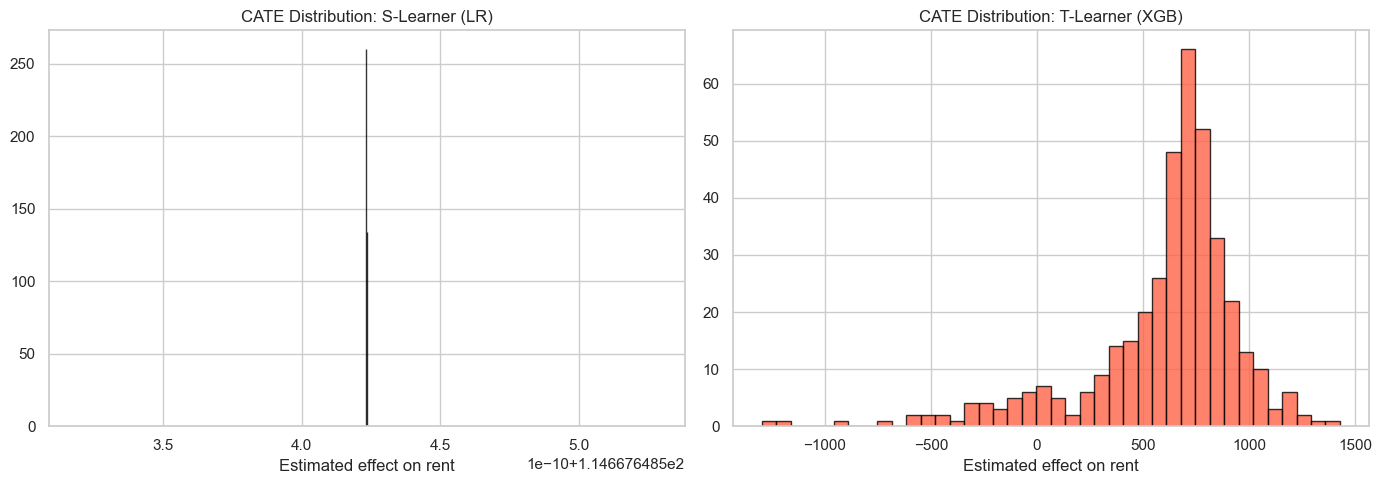


CATE summary by transit_tier:


,mean,std,count
transit_tier,,,
none,628.730538,328.616759,340
low,512.918062,569.259295,42
medium,131.149119,392.460032,12



CATE summary by safety_tier:


,mean,std,count
safety_tier,,,
safe,633.932811,214.051782,51
higher_risk,596.893827,395.530246,334
moderate,576.846598,215.711160,9



CATE summary by food_access_tier:


,mean,std,count
food_access_tier,,,
food_q3,728.371053,184.867549,90
food_q2,715.384012,165.897791,102
food_q1,693.798211,250.075146,107
food_q4,253.955351,538.091718,95


In [164]:
# Visualize CATE heterogeneity
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_causal['CATE_LR'], bins=40, color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_title('CATE Distribution: S-Learner (LR)')
axes[0].set_xlabel('Estimated effect on rent')

axes[1].hist(df_causal['CATE_XGB'], bins=40, color='tomato', edgecolor='black', alpha=0.8)
axes[1].set_title('CATE Distribution: T-Learner (XGB)')
axes[1].set_xlabel('Estimated effect on rent')

plt.tight_layout()
plt.show()

# Summaries by key neighborhood tiers
summary_cols = ['transit_tier', 'safety_tier', 'food_access_tier']
for c in summary_cols:
    if c in df_causal.columns:
        print(f'\nCATE summary by {c}:')
        display(df_causal.groupby(c)['CATE_XGB'].agg(['mean', 'std', 'count']).sort_values('mean', ascending=False))


## Causal Interpretation Notes
- `ATE_rent_delta > 0`: higher transit access causally increases rent on average.
- CATE distributions show where the effect is strongest or weakest across neighborhood profiles.
- This is observational causal inference, so interpretation still depends on measured-confounder quality.


## Step 5: Absolute Causal Impact Ranking (Magnitude)

This view ranks treatments by absolute effect size (`|ATE_XGB|`) and keeps direction labels, so we can separate:
- strongest rent-increasing drivers (`ATE_XGB > 0`)
- strongest rent-decreasing drivers (`ATE_XGB < 0`)
- strongest overall impact regardless of sign (`|ATE_XGB|`)


In [ ]:
if 'ranking_df' not in globals() or ranking_df.empty:
    print('Re-run step 4.')
else:
    abs_ranking_df = ranking_df.copy()
    abs_ranking_df['abs_ATE_XGB'] = abs_ranking_df['ATE_XGB'].abs()
    abs_ranking_df['rent_direction'] = np.where(
        abs_ranking_df['ATE_XGB'] > 0,
        'increases_rent',
        np.where(abs_ranking_df['ATE_XGB'] < 0, 'decreases_rent', 'no_effect')
    )
    abs_ranking_df = abs_ranking_df.sort_values('abs_ATE_XGB', ascending=False).reset_index(drop=True)

    abs_out = OUTPUT_DIR / 'causal_rent_treatment_ranking_absolute.csv'
    abs_ranking_df.to_csv(abs_out, index=False)

    print('Absolute causal impact ranking (largest |ATE_XGB| first):')
    display(abs_ranking_df[['treatment', 'treatment_variable', 'ATE_XGB', 'abs_ATE_XGB', 'rent_direction', 'ATE_XGB_CI_low', 'ATE_XGB_CI_high']])

    top_abs = abs_ranking_df.iloc[0]
    print('Top absolute-impact treatment:')
    print('- {} ({}) | ATE_XGB={:.2f} | direction={}'.format(
        top_abs['treatment'], top_abs['treatment_variable'], top_abs['ATE_XGB'], top_abs['rent_direction']
    ))
    print('Saved:', abs_out)


Absolute causal impact ranking (largest |ATE_XGB| first):


,treatment,treatment_variable,ATE_XGB,abs_ATE_XGB,rent_direction,ATE_XGB_CI_low,ATE_XGB_CI_high
0,high_crime,crime_count_in_circle,-277.227262,277.227262,decreases_rent,-335.824867,-218.629657
1,high_transit_access,subway_count_in_circle,93.055668,93.055668,increases_rent,44.815814,141.295521
2,large_service_radius,radius_m,-48.495286,48.495286,decreases_rent,-98.799818,1.809245
3,high_violent_crime_ratio,violent_crime_ratio_in_circle,-36.887765,36.887765,decreases_rent,-85.103823,11.328294
4,high_food_access,restaurant_count_in_circle,-30.139113,30.139113,decreases_rent,-81.348488,21.070262


Top absolute-impact treatment:
- high_crime (crime_count_in_circle) | ATE_XGB=-277.23 | direction=decreases_rent
Saved: ..\outputs\eda\causal_rent_treatment_ranking_absolute.csv


## Step 6: Causal Deep Dive for Crime (Effect on Rent)

This section performs a focused causal analysis for crime intensity and rent.
Treatment is defined as high crime exposure (`crime_count_in_circle` above median).


In [166]:
df_crime_causal = fe.copy()
df_crime_causal['outcome_rent'] = pd.to_numeric(df_crime_causal['mean_rent'], errors='coerce')
df_crime_causal['crime_count_in_circle'] = pd.to_numeric(df_crime_causal['crime_count_in_circle'], errors='coerce')

crime_threshold = float(df_crime_causal['crime_count_in_circle'].median())
df_crime_causal['treatment_high_crime'] = (df_crime_causal['crime_count_in_circle'] >= crime_threshold).astype(int)

crime_candidate_confounders = [
    'cell_area_km2',
    'radius_m',
    'restaurant_count_in_circle',
    'subway_count_in_circle',
    'violent_crime_count_in_circle',
    'violent_crime_ratio_in_circle',
]

df_crime_causal = df_crime_causal.dropna(subset=['outcome_rent', 'crime_count_in_circle']).copy()
crime_available_confounders = [c for c in crime_candidate_confounders if c in df_crime_causal.columns]

print('Crime threshold (median):', round(crime_threshold, 3))
print('Data shape:', df_crime_causal.shape)
print('Treatment share (high crime):', round(df_crime_causal['treatment_high_crime'].mean(), 4))
print('Outcome mean rent:', round(df_crime_causal['outcome_rent'].mean(), 2))
print('Available confounders:', crime_available_confounders)


Crime threshold (median): 189.0
Data shape: (394, 49)
Treatment share (high crime): 0.5
Outcome mean rent: 2375.8
Available confounders: ['cell_area_km2', 'radius_m', 'restaurant_count_in_circle', 'subway_count_in_circle', 'violent_crime_count_in_circle', 'violent_crime_ratio_in_circle']


In [167]:
# Confounder screening for crime treatment
crime_sens_rows = []
treated = df_crime_causal[df_crime_causal['treatment_high_crime'] == 1]
control = df_crime_causal[df_crime_causal['treatment_high_crime'] == 0]

for col in crime_available_confounders:
    t = pd.to_numeric(treated[col], errors='coerce')
    c = pd.to_numeric(control[col], errors='coerce')

    pooled_std = np.sqrt((t.var(ddof=1) + c.var(ddof=1)) / 2)
    smd = (t.mean() - c.mean()) / pooled_std if pooled_std and not np.isnan(pooled_std) else 0.0
    corr = df_crime_causal[[col, 'outcome_rent']].corr().iloc[0, 1]

    crime_sens_rows.append({
        'variable': col,
        'abs_smd': abs(float(smd)),
        'abs_corr_with_rent': abs(float(corr)) if pd.notna(corr) else 0.0,
    })

crime_sens_df = pd.DataFrame(crime_sens_rows)
crime_sens_df['confounder_score'] = crime_sens_df['abs_smd'] * crime_sens_df['abs_corr_with_rent']
crime_sens_df = crime_sens_df.sort_values('confounder_score', ascending=False).reset_index(drop=True)
crime_selected_confounders = crime_sens_df.head(min(5, len(crime_sens_df)))['variable'].tolist()

print('Crime confounder screening:')
display(crime_sens_df)
print('Selected confounders:', crime_selected_confounders)


Crime confounder screening:


,variable,abs_smd,abs_corr_with_rent,confounder_score
0,violent_crime_ratio_in_circle,0.714015,0.137018,0.097833
1,restaurant_count_in_circle,1.003691,0.049743,0.049927
2,cell_area_km2,0.788483,0.056480,0.044533
3,radius_m,1.056776,0.041430,0.043783
4,subway_count_in_circle,0.415346,0.046952,0.019501
5,violent_crime_count_in_circle,0.750134,0.021649,0.016239


Selected confounders: ['violent_crime_ratio_in_circle', 'restaurant_count_in_circle', 'cell_area_km2', 'radius_m', 'subway_count_in_circle']


In [168]:
# Estimate ATE/CATE for high crime treatment
Y_crime = df_crime_causal['outcome_rent'].values
T_crime = df_crime_causal['treatment_high_crime'].values
X_crime = df_crime_causal[crime_selected_confounders].replace([np.inf, -np.inf], np.nan).fillna(0.0)

crime_effects = estimate_ate_cate_pair(X=X_crime, T=T_crime, Y=Y_crime)

df_crime_causal['CATE_LR_crime'] = crime_effects['CATE_LR']
df_crime_causal['CATE_XGB_crime'] = crime_effects['CATE_XGB']

crime_ate_results = pd.DataFrame({
    'method': ['S-Learner (Linear Regression)', 'T-Learner (XGBoost)'],
    'ATE_rent_delta': [crime_effects['ATE_LR'], crime_effects['ATE_XGB']],
    'CI_lower': [crime_effects['ATE_LR_CI_low'], crime_effects['ATE_XGB_CI_low']],
    'CI_upper': [crime_effects['ATE_LR_CI_high'], crime_effects['ATE_XGB_CI_high']],
})

print('Crime causal deep dive: effect of HIGH crime on rent (treated - control)')
print('Engine used:', crime_effects['engine'])
display(crime_ate_results)


Crime causal deep dive: effect of HIGH crime on rent (treated - control)
Engine used: causalml


,method,ATE_rent_delta,CI_lower,CI_upper
0,S-Learner (Linear Regression),-136.675469,-244.060491,-29.290447
1,T-Learner (XGBoost),-277.227262,-335.824867,-218.629657


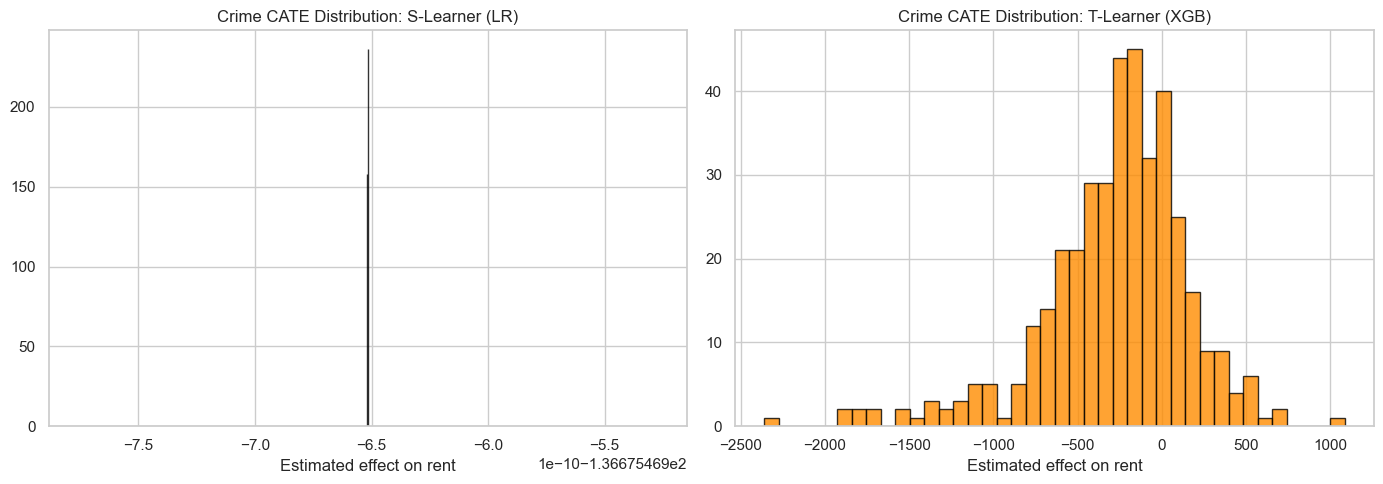

Crime effect heterogeneity by transit tier:


,mean,std,count
transit_tier,,,
medium,-493.645874,651.634219,12
none,-281.793899,385.305355,340
low,-178.425360,711.874327,42


Crime effect heterogeneity by food access tier:


,mean,std,count
food_access_tier,,,
food_q4,-439.724501,650.244222,95
food_q1,-334.656291,367.628074,107
food_q2,-228.787202,283.408871,102
food_q3,-92.324398,307.115639,90


In [169]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df_crime_causal['CATE_LR_crime'], bins=40, color='slateblue', edgecolor='black', alpha=0.8)
axes[0].set_title('Crime CATE Distribution: S-Learner (LR)')
axes[0].set_xlabel('Estimated effect on rent')

axes[1].hist(df_crime_causal['CATE_XGB_crime'], bins=40, color='darkorange', edgecolor='black', alpha=0.8)
axes[1].set_title('Crime CATE Distribution: T-Learner (XGB)')
axes[1].set_xlabel('Estimated effect on rent')

plt.tight_layout()
plt.show()

if 'transit_tier' in df_crime_causal.columns:
    print('Crime effect heterogeneity by transit tier:')
    display(df_crime_causal.groupby('transit_tier')['CATE_XGB_crime'].agg(['mean', 'std', 'count']).sort_values('mean'))

if 'food_access_tier' in df_crime_causal.columns:
    print('Crime effect heterogeneity by food access tier:')
    display(df_crime_causal.groupby('food_access_tier')['CATE_XGB_crime'].agg(['mean', 'std', 'count']).sort_values('mean'))


### Crime Deep Dive Interpretation
- `ATE_rent_delta < 0`: high crime is estimated to reduce rent on average.
- `ATE_rent_delta > 0`: high crime is estimated to increase rent on average.
- CATE spread shows where crime impact on rent is strongest or weakest by neighborhood profile.


## **Conclusion: Causal Inference Findings for Rent**

This notebook's causal analysis indicates that the direction and magnitude of effects are different, so the conclusion depends on whether the goal is "increase rent" or "largest overall impact".

### 1) Primary conclusion for rent-increasing drivers
- The strongest estimated **rent-increasing** treatment is **high transit access** (`subway_count_in_circle > 0`).
- Estimated effect (XGBoost T-learner): **ATE = +93.06** rent units, 95% CI **[+44.82, 141.30]**.
- Interpretation: after controlling for measured confounders, areas with transit access are estimated to have materially higher rent.

### 2) Absolute-impact conclusion (magnitude regardless of sign)
- The strongest estimated **overall causal impact** by absolute value is **high crime** (`crime_count_in_circle >= median`).
- Estimated effect (XGBoost T-learner): **ATE = -277.22** rent units, 95% CI **[-335.82, -218.63]**.
- Interpretation: high crime is associated with a large **rent-decreasing** causal effect. It is the largest effect in magnitude, but not a rent-increasing driver.